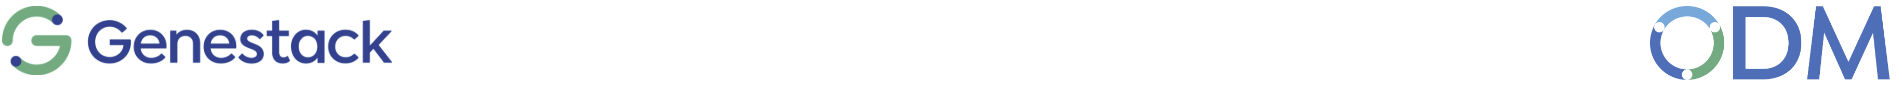

# The Single-Cell Module Exploration

**This Notebook is designed to introduce you to the Single-Cell Module in ODM and to show several possible applications of the features it has.** Newly added analytical queries enable users to quickly test hypotheses directly in ODM without downloading heavy data files.

**With this Notebook and the harmonised ODM instance users will be able:**
- To filter queries by any metadata fields
- To unite data from several datasets and to track dataset-specific signals
- To calculate gene summary, cell ratios and single-cell differential expression server-side by filling in the filters in the Notebook
- To compare bulk and single-cell differential gene expression

This example covers a common case of the possible targets hidden in bulk transcriptomics that can be found with the single-cell data. It focuses on large intestine-derived samples in ulcerative colitis yet the prepared instance contains other inflammatory conditions that can be investigated too.

## We hope that this example will inspire you to further explore the capabilities of the Single-Cell Module and to test your own hypotheses.

**Contact:** support@genestack.com &nbsp;·&nbsp; © 2026 Genestack.

---

## Prerequisites
Run this section for the initialization and setup.

### Installation

From the unzipped demo folder (the directory that contains `setup.py` and `demo_utils/`), install the local helper package and dependencies into the active notebook kernel.

In [1]:
from pathlib import Path
from importlib.metadata import distribution

ROOT = Path.cwd() # or Path('/path/to/demo/folder')

try:
    distribution('demo_utils')
    print('demo_utils already installed')
except Exception:
    %pip install -e "{ROOT}"

demo_utils already installed


Alternatively, you can install the dependencies into the Python environment (must be the same as the notebook kernel) via the terminal command:
```bash
python -m pip install -e .
```

### Imports
This subsection imports needed modules and packages.

In [2]:
# standard libraries (come with Python)
import os
import warnings
import contextlib
from io import StringIO

# third-party libraries (require installation)
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import false_discovery_control

# Genestack ODM API (comes with odm-sdk)
import odm_api
from odm_api.models.cr_request import CRRequest
from odm_api.models.de_request_case_group import DERequestCaseGroup
from odm_api.models.de_request import DERequest
from odm_api.models.gs_request import GSRequest

# local helper functions
from demo_utils import (
    
    # connection / instrumentation
    set_api_configuration,
    odm_timer,

    # shared utilities
    build_sample_filter,
    get_all_data,
    scalar_value,
    camel_case_keys,

    # step 1 — data landscape
    display_data_type_card,
    plot_bulk_sc_groups_summary,
    display_collapsible_table,

    # step 2 — bulk
    run_bulk_de,
    run_bulk_de_deseq2,
    display_bulk_de_card,
    display_bulk_de_table,
    plot_bulk_de_heatmap,

    # step 3 — single-cell
    plot_cell_type_proportions_comparison,
    score_cell_specificity,
    plot_sc_dotplot,
    get_top_cell_types,
    plot_sc_dotplot_and_cell_summary_source_comparison,
    plot_cell_composition,

    # step 4 — bulk vs SC
    plot_bulk_sc_de_comparison,
    display_bulk_sc_de_comparison_panel,

    # step 5 — pathways
    run_gsea_per_cell_type,
    plot_gsea_dotplot,

    # closing summary
    display_bulk_sc_comparison_summary,
    display_data_landscape,
)

# local settings
plt.style.use('default')
warnings.filterwarnings('ignore', category=FutureWarning)

### Authentication
Run this cell to set ODM API credentials. Either enter your ODM token manually in the interactive form, or store it in a `.env` file as `ODM_API_TOKEN=...`.

If Azure authentication is available for your account, instead set `use_azure_auth=True` in `set_api_configuration` and sign in through the **interactive browser-based Microsoft Azure authentication**.

In [3]:
server = 'https://single-cell-evaluation.dev.gs.team'

api_client = set_api_configuration(server, use_azure_auth=False)

'ODM_API_TOKEN' not found in environment or .env. Falling back to manual input.
Token authentication successful! Docs: https://single-cell-evaluation.dev.gs.team/user-docs/tools/odm-api/python/generated/


## What can be done with this Notebook

Main question: *Which genes that are the known disease drivers can be discovered specifically with single-cell analysis?*

1. **Explore available data:** What data exists on the instance?
2. **Bulk data analysis:** Which genes are differentially expressed on **tissue** level?
3. **Single-cell data analysis:** Which genes are differentially expressed on **cell** level?
4. **Compare:** What hidden insights can be found on cell resolution?
5. **Insights:** Further steps that can be done after the main analysis. We are going to explore which metabolic pathways are up- or downregulated in different cell types.

Each step involves cross-study queries across all data in ODM. The blue **⏱ timers** show query running time.

---
Expected result of this demo is an easy comparison of bulk and single-cell DEGs.

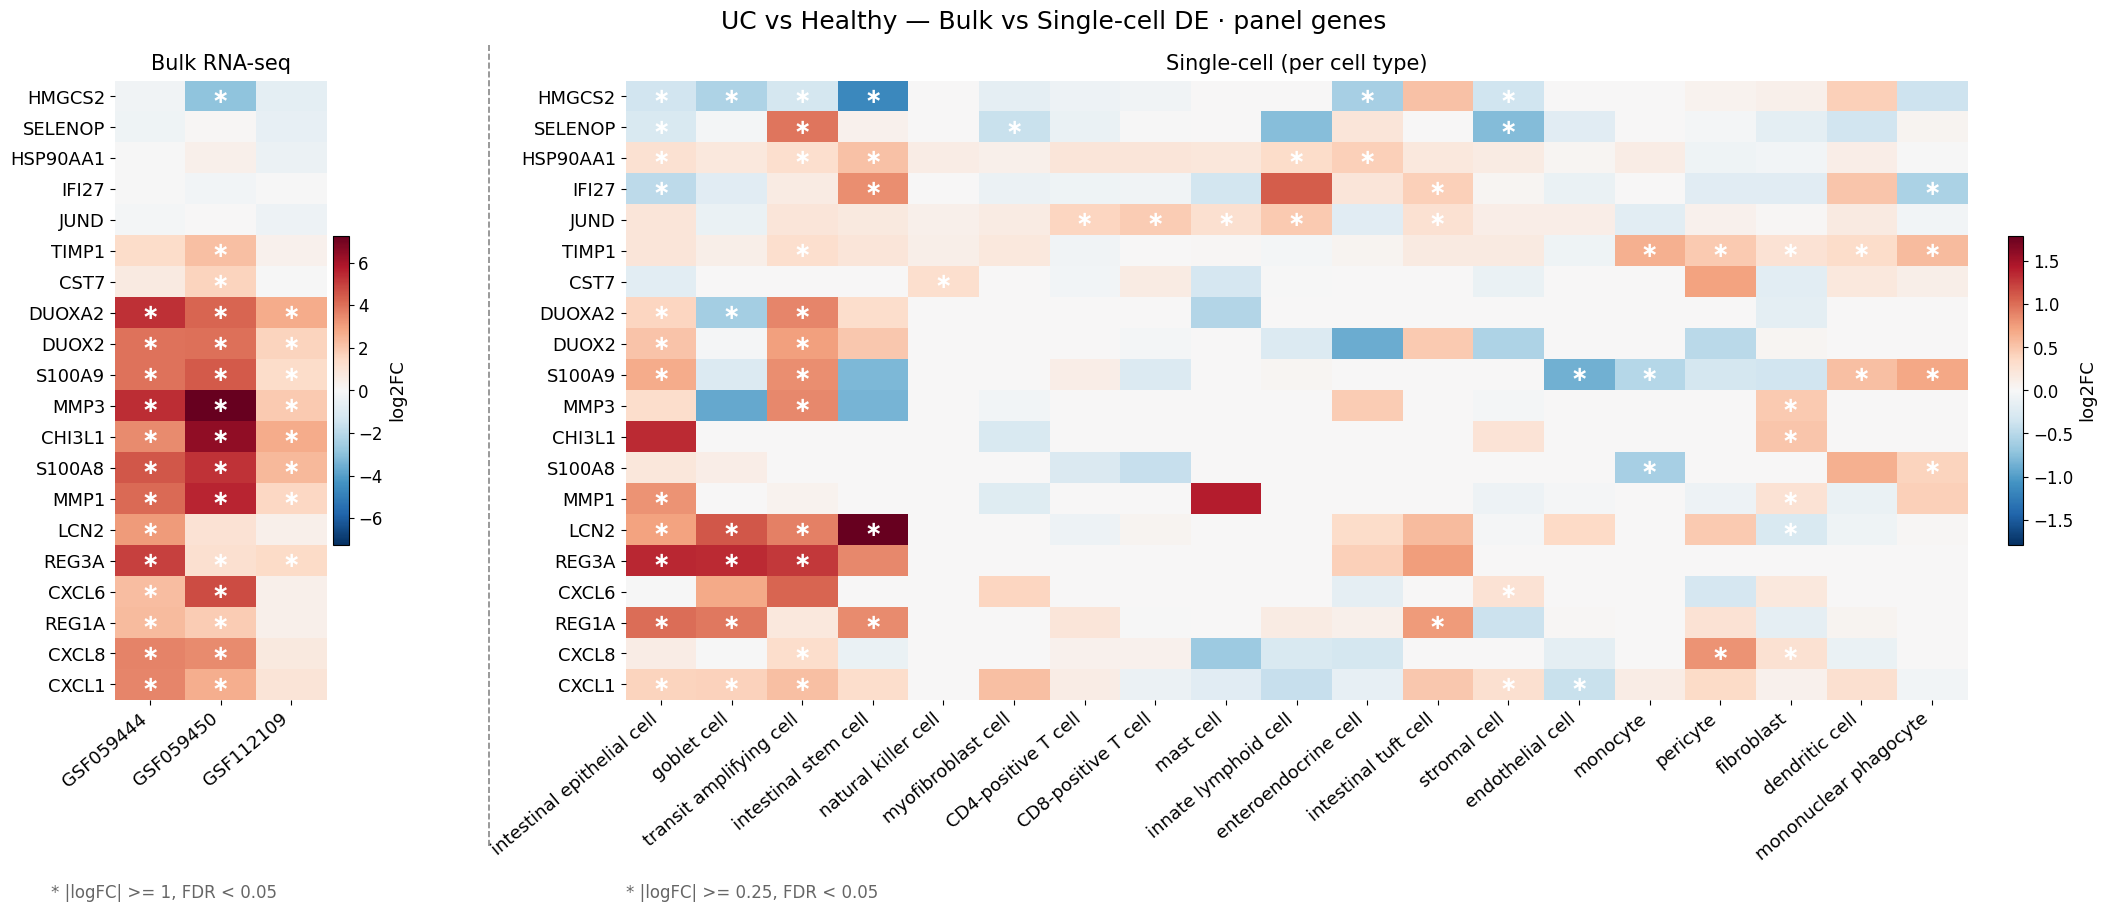

## Step 1 · Explore available data

**What conditions are available for analysis and how are samples and cells distributed between them?**

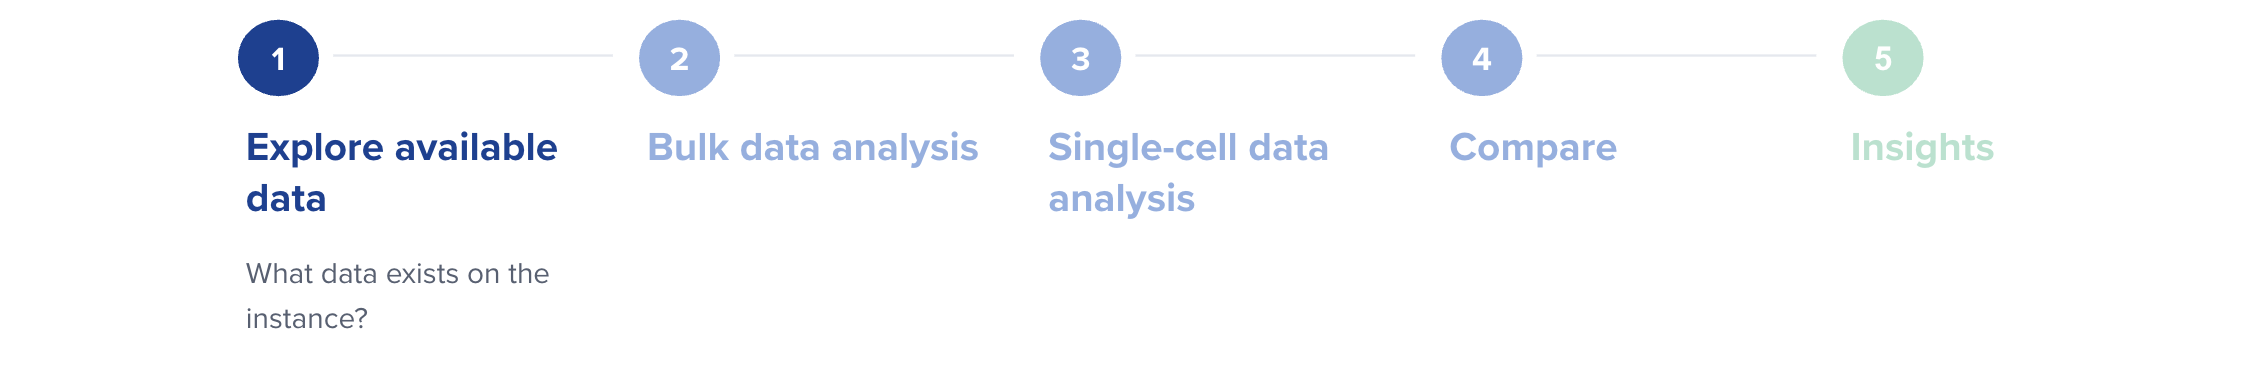

### 1.1 Quick overview 
Check the data available in ODM. One ODM study may contain several datasets.

In [4]:
def count_studies(api_client, **kwargs):
    """
    Count the number of studies in the dataset that match the given filters.

    Parameters:
    - api_client (odm_api.ApiClient): Authenticated API client.
    - **kwargs (dict): Optional keyword arguments for the `search_studies` API call.
        e.g. `{'filter': '"Therapeutic Area"="Gastrointestinal Disorders"'}`.

    Returns:
    - int: The number of studies that match the filters.
    """
    study_api = odm_api.StudySPoTAsUserApi(api_client)
    studies = get_all_data(study_api.search_studies_as_user, **kwargs)
    return len(studies) if studies else 0


def count_cells(api_client, ex_query=None, **kwargs):
    """
    Count the number of cells in the dataset that match the given filters.

    Parameters:
    - api_client (odm_api.ApiClient): API client instance.
    - ex_query (str): Features to query (e.g. 'feature=MKI67,TOP2A').
    - **kwargs (dict): Optional keyword arguments for the `DERequestCaseGroup` request model,
        e.g. `{'sampleFilter': 'Organism="Homo sapiens"'}`.

    Returns:
    - int: The number of cells that match the filters.
    """
    analytics_api = odm_api.BETAAnalyticsOmicsQueriesAsUserApi(api_client)
    cell_group_params = camel_case_keys(kwargs)
    cells = analytics_api.cell_ratio_as_user(
        cr_request=CRRequest(
            cellGroup=DERequestCaseGroup(**cell_group_params),
            exQuery=ex_query
        )
    )
    return int(getattr(cells, 'count_available', 0) or getattr(cells, 'count_selected', 0) or 0)


def count_data_classes(api_client, **kwargs):
    """
    Count unique expression-group datasets by Data Class.

    Parameters:
    - api_client (odm_api.ApiClient): Authenticated API client.
    - **kwargs (dict): Optional keyword arguments for the 'omics_search' API call,
        e.g. `{'sample_filter': 'Organism="Homo sapiens"'}`.

    Returns:
    - dc_counts (pandas.Series): Counts per data class.
    """
    omics_api = odm_api.OmicsQueriesAsUserApi(api_client)

    # search expression groups
    ex_groups = get_all_data(
        omics_api.omics_search_expression_groups_as_user,
        returned_metadata_fields="original_data_included",
        **kwargs
    )
    ex_groups_df = pd.DataFrame([
        {'Group ID': item['itemId'], **item['metadata']}
        for item in ex_groups
    ])

    # count number of expression groups per data class
    ex_groups_df['Data Class'] = (
        ex_groups_df['Data Class'].apply(scalar_value) 
        if 'Data Class' in ex_groups_df.columns else ''
    )
    dc_counts = ex_groups_df.groupby('Data Class')['Group ID'].nunique()
    
    return dc_counts


# --- get number of entities ---
with odm_timer('Retrieving datasets per data type', key='platform_overview'):
    n_studies = count_studies(api_client)
    total_cells = count_cells(api_client)
    dc_counts = count_data_classes(api_client)
    n_bulk_datasets = int(dc_counts.get('Bulk transcriptomics', 0))
    n_sc_datasets = int(dc_counts.get('Single-cell transcriptomics', 0))

# --- show platform data overview card ---
display_data_type_card(n_studies, n_bulk_datasets, n_sc_datasets, total_cells)

### 1.2 More detailed view
Check the distribution of bulk transcriptomics samples and cells per condition.

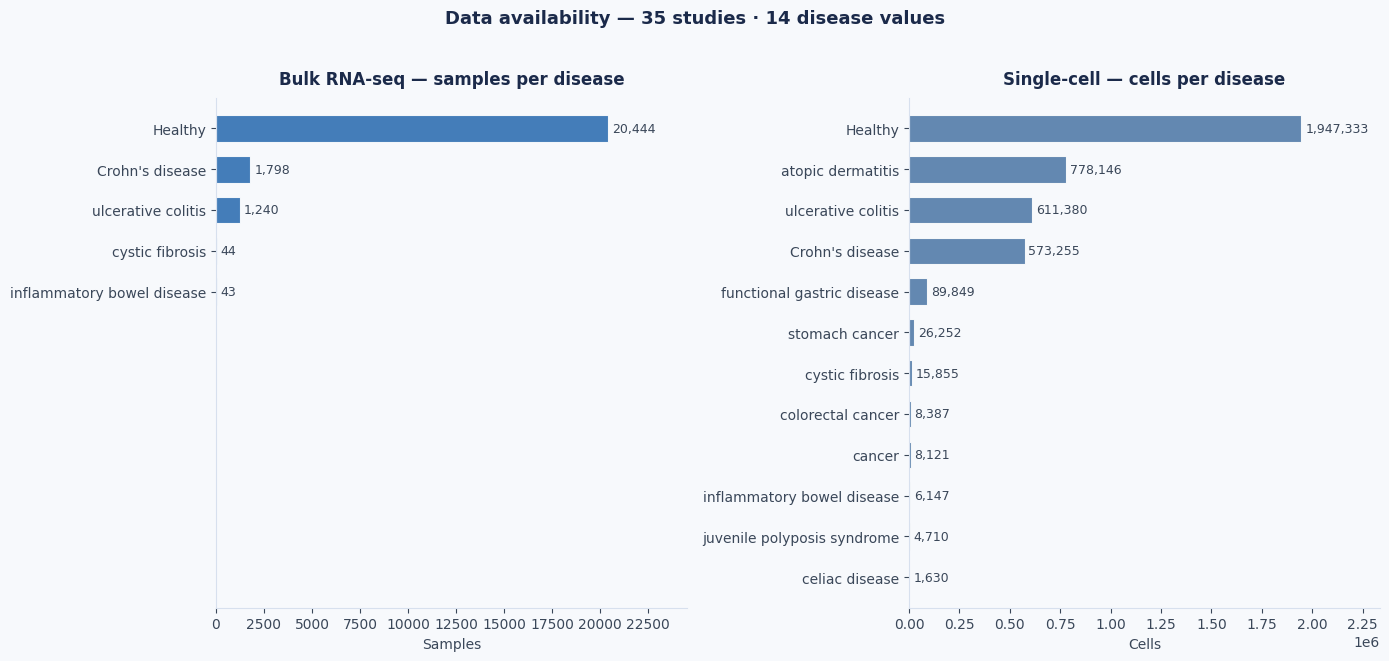

In [5]:
GROUP_ATTRIBUTE = 'Disease' # set the sample metadata attribute to group by


def get_sample_metadata(api_client, **kwargs):
    """
    Get sample metadata.

    Parameters:
    - api_client (odm_api.ApiClient): API client instance.
    - **kwargs (dict): Optional keyword arguments for the 'omics_search' API call,
        e.g. `{'sample_filter': 'Organism="Homo sapiens"'}`.

    Returns:
    - metadata_df (pd.DataFrame): Biosample metadata.
    """
    omics_api = odm_api.OmicsQueriesAsUserApi(api_client)

    # get sample metadata
    sample_metadata = get_all_data(
        omics_api.omics_search_samples_as_user,
        returned_metadata_fields="original_data_included",
        **kwargs
    )
    samples_df = pd.DataFrame.from_dict([item['metadata'] for item in sample_metadata])

    return samples_df


def count_samples(api_client, **kwargs):
    """
    Count the number of samples in the dataset that match the given filters.

    Parameters:
    - api_client (odm_api.ApiClient): API client instance.
    - **kwargs (dict): Optional keyword arguments for the `omics_search` API call,
        e.g. `{'sample_filter': 'Organism="Homo sapiens"'}`

    Returns:
    - int: The number of samples that match the filters.
    """
    omics_api = odm_api.OmicsQueriesAsUserApi(api_client)
    samples = get_all_data(
        omics_api.omics_search_samples_as_user,
        **kwargs
    )
    return len(samples) if samples else 0


# --- get counts of bulk samples and cells per group ---
with odm_timer(f'Bulk samples and cells per {GROUP_ATTRIBUTE.lower()}'):

    # get sample metadata
    samples_df = get_sample_metadata(api_client)    
    samples_df[GROUP_ATTRIBUTE] = (
        samples_df[GROUP_ATTRIBUTE].apply(scalar_value) 
        if GROUP_ATTRIBUTE in samples_df.columns else ''
    )
    top_groups  = samples_df[GROUP_ATTRIBUTE].value_counts().head(15).index.tolist()
    n_groups    = int(samples_df[GROUP_ATTRIBUTE].nunique())

    # get counts of bulk samples and cells for top groups
    sc_counts = {}
    bulk_counts = {}
    for g in top_groups:

        # per-group SC cell count
        group_params = {'sample_filter': f'"{GROUP_ATTRIBUTE}"="{g}"'}
        sc_counts[g] = count_cells(api_client, **group_params)

        # per-group bulk count
        bulk_params = {'ex_filter': '"Data Class"="Bulk transcriptomics"', **group_params}
        bulk_counts[g] = count_samples(api_client, **bulk_params)

# --- show group counts summary ---
group_df = pd.DataFrame({
    'group':        top_groups,
    'bulk_samples': [bulk_counts[g] for g in top_groups],
    'sc_cells':     [sc_counts[g]   for g in top_groups],
})
plot_bulk_sc_groups_summary(
    group_df,
    n_studies,
    n_groups,
    group_attribute=GROUP_ATTRIBUTE,
)

## Step 2 · Bulk transcriptomics

**There are genes that are known to be involved in a certain condition. How many of them are significant when we run DE analysis on the selected cohort of the bulk transcriptomics data?**

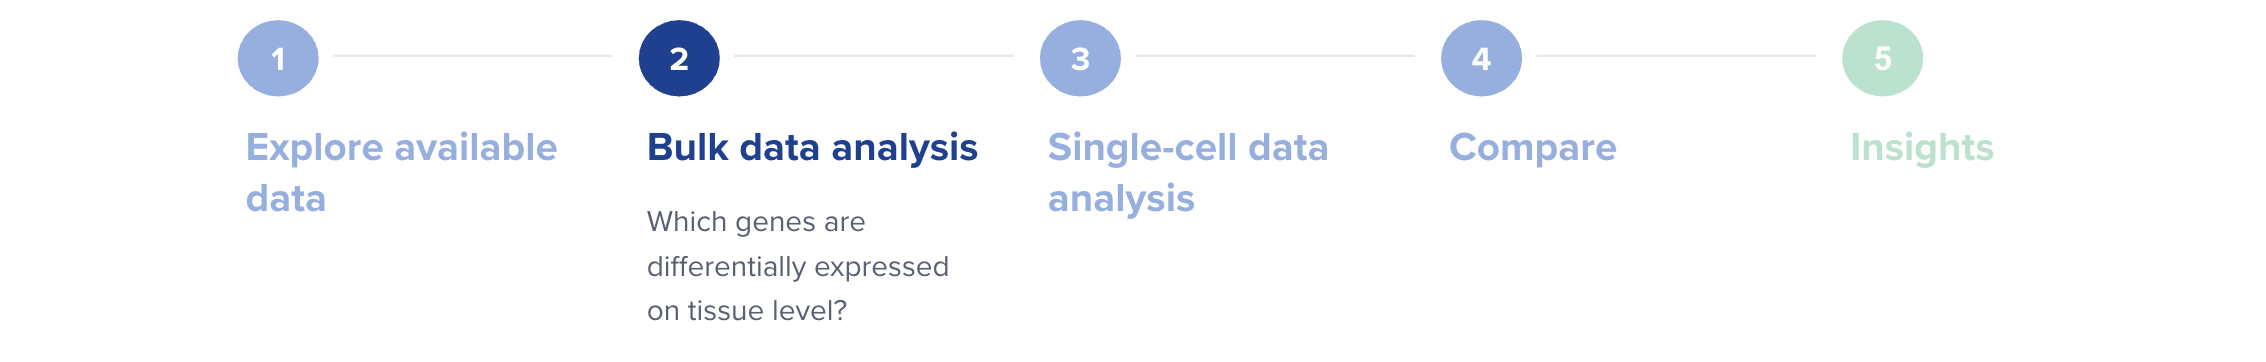

### 2.1 Configure the cohort parameters

Edit this cell once — group attribute, case/control values, display labels, and shared sample filters. The rest of the notebook derives filters, inventory columns, and plot labels from these settings.


In [6]:
# cohort config
GROUP_ATTRIBUTE = 'Disease'              # e.g. Disease, Treatment, Condition
CASE_GROUP      = 'ulcerative colitis'   # value of GROUP_ATTRIBUTE for case
CTRL_GROUP      = 'Healthy'              # value of GROUP_ATTRIBUTE for control
CASE_LABEL      = 'UC'                   # short label used in plots / tables
CTRL_LABEL      = 'Healthy'
CASE_COL        = f'{CASE_LABEL} samples'
CTRL_COL        = f'{CTRL_LABEL} samples'

SHARED_FILTERS  = {'Tissue General': 'large intestine'}  # AND-ed into every sample filter
MIN_SAMPLES     = 5

CASE_FILTER = build_sample_filter(CASE_GROUP, GROUP_ATTRIBUTE, SHARED_FILTERS)
CTRL_FILTER = build_sample_filter(CTRL_GROUP, GROUP_ATTRIBUTE, SHARED_FILTERS)
CONTRAST_LABEL = f'{CASE_LABEL} vs {CTRL_LABEL}'
TISSUE = SHARED_FILTERS.get('Tissue General')  # convenience alias when present

print(f'Cohort: {CONTRAST_LABEL} · {GROUP_ATTRIBUTE}={CASE_GROUP!r} / {CTRL_GROUP!r}')
if SHARED_FILTERS:
    print('Shared filters:', ', '.join(f'{k}={v!r}' for k, v in SHARED_FILTERS.items()))

Cohort: UC vs Healthy · Disease='ulcerative colitis' / 'Healthy'
Shared filters: Tissue General='large intestine'


### 2.2 Retrieve suitable bulk datasets
For the further DE analysis we would need the studies that contain both case and control samples and data without log transformation. In addition to the specific case and control group filters (e.g. condition and tissue), the filtering is done by assay type, minimal number of samples and normalization method.

In [7]:
def get_expression_group_metadata(api_client, **kwargs):
    """
    Get expression group metadata for a list of genes.

    Parameters:
    - api_client (odm_api.ApiClient): API client instance.
    - **kwargs (dict): Additional keyword arguments for the API call,
        e.g. `{'sample_filter': 'Organism="Homo sapiens"'}`.

    Returns:
    - ex_groups_df (pd.DataFrame): Expression group metadata.
    """
    omics_api = odm_api.OmicsQueriesAsUserApi(api_client)

    # search expression groups
    ex_groups = get_all_data(
        omics_api.omics_search_expression_groups_as_user,
        returned_metadata_fields="original_data_included",
        **kwargs
    )
    ex_groups_df = pd.DataFrame([
        {'Group ID': item['itemId'], **item['metadata']}
        for item in ex_groups
    ])

    return ex_groups_df


# --- get suitable bulk RNA-seq datasets ---
with odm_timer('Scanning datasets and counting samples per group'):
  
    # get bulk RNA-seq expression groups
    rnaseq_groups_df = get_expression_group_metadata(api_client)
    rnaseq_groups_df['Normalization Method'] = rnaseq_groups_df['Normalization Method'].apply(scalar_value)
    rnaseq_groups_df['Assay Type'] = rnaseq_groups_df['Assay Type'].apply(scalar_value)
    rnaseq_groups_df = rnaseq_groups_df[rnaseq_groups_df['Assay Type'] == 'Bulk RNA-seq']

    # sample counts per expression group per case/control filter
    inventory_rows = []
    for _, row in rnaseq_groups_df.iterrows():
        ex_params = {'ex_filter': f'"genestack:accession"="{row["Group ID"]}"'}
        case_params = {'sample_filter': CASE_FILTER, **ex_params}
        ctrl_params = {'sample_filter': CTRL_FILTER, **ex_params}
        inventory_rows.append({
            'Group ID':             row['Group ID'],
            'Normalization Method': row['Normalization Method'],
            CASE_COL:               count_samples(api_client, **case_params),
            CTRL_COL:               count_samples(api_client, **ctrl_params),
        })
    inventory_df = pd.DataFrame(inventory_rows)

    # filter suitable datasets
    viable = inventory_df[
        (inventory_df[CASE_COL] >= MIN_SAMPLES) &
        (inventory_df[CTRL_COL] >= MIN_SAMPLES) &
        inventory_df['Normalization Method'].str.contains(
            'no log-transformation|Raw counts, no normalization', case=False, na=False)
    ].copy()
    viable['ex_filter'] = viable['Group ID'].apply(lambda g: f'"genestack:accession"="{g}"')


# --- show suitable bulk RNA-seq datasets ---
print(
    f"{len(rnaseq_groups_df)} bulk RNA-seq datasets scanned — {len(viable)} suitable "
    f"(≥{MIN_SAMPLES} {CASE_LABEL} and ≥{MIN_SAMPLES} {CTRL_LABEL} samples, no log-transformation)."
)
display_collapsible_table(
    "Show all datasets",
    inventory_df.to_html(index=False),
)

22 bulk RNA-seq datasets scanned — 3 suitable (≥5 UC and ≥5 Healthy samples, no log-transformation).


Group ID,Normalization Method,UC samples,Healthy samples
GSF049994,"Raw counts, no normalization",0,0
GSF049996,TPM,0,0
GSF050043,"Raw counts, no normalization",0,0
GSF050045,TPM,0,0
GSF052098,"Raw counts, no normalization",0,0
GSF052199,TMM,0,0
GSF052303,"CPM, TMM",27,0
GSF052553,"CPM, TMM",26,0
GSF052758,"CPM, TMM",42,29
GSF053036,"TMM, log-transformation",30,50


### 2.3 Define the gene panel
Here the gene panel for the further comparison is defined. For this case we chose 20 genes that were mentioned in the scientific literature as involved in the ulcerative colitis pathogenesis.

This list can be changed in accordance with the user's needs. If no gene names are pasted to the list, all genes available in ODM will be analysed.


In [8]:
# Candidate gene panel (20 genes)
genes = [
    'LCN2',      # lipocalin-2 (NGAL); siderophores-sequestering bacteriostatic protein; fecal biomarker of intestinal mucosal inflammation; pro-inflammatory and iron-regulatory roles
    'DUOX2',     # epithelial NADPH oxidase generating H2O2 at the mucosal surface; innate defence against luminal pathogens
    'S100A9',    # calprotectin component (with S100A8); TLR4 and RAGE ligand activating innate immunity; basis of fecal calprotectin test
    'MMP3',      # broad-spectrum metalloprotease degrading collagens, fibronectin, casein, laminin, and proteoglycans; activates other proMMPs; drives mucosal ECM remodeling
    'CXCL8',     # IL-8; master neutrophil chemoattractant; promotes neutrophil transepithelial migration into the gut lumen
    'REG1A',     # C-type lectin secreted by intestinal epithelial cells; IL-6 and IL-22-induced; anti-inflammatory, protective, and epithelial repair roles
    'HMGCS2',    # rate-limiting enzyme in colonocyte ketogenesis; loss reflects mitochondrial metabolic failure in inflamed epithelium
    'CXCL1',     # GRO-α; potent CXCR2 ligand recruiting neutrophils across the epithelial barrier
    'CHI3L1',    # YKL-40; macrophage/fibroblast-secreted chitinase-like glycoprotein; is involved in inflammation, apoptosis, and extracellular matrix remodeling; elevated serum or feces levels correlate with UC disease activity and endoscopic severity
    'TIMP1',     # tissue inhibitor of metalloproteinase-1; also carries out MMP-inhibition-independent pro-survival cytokine-like signaling
    'DUOXA2',    # maturation factor required for DUOX2 oxidase activity at the mucosal surface
    'CST7',      # cystatin F; cathepsin inhibitor in cytotoxic lymphocytes; suppresses cytotoxic activity in NK and CD8+ T cells
    'S100A8',    # calgranulin-A; forms calprotectin heterodimer with S100A9; amplifies NF-κB and promotes neutrophil recruitment
    'MMP1',      # collagenase-1; degrades interstitial collagens I–III; activated in inflamed mucosa driving ulceration
    'IFI27',     # interferon-α-inducible protein; mediates ISG-driven apoptosis; marker of type-I interferon pathway activation
    'REG3A',     # antimicrobial C-type lectin targeting gram-positive bacteria; induced at the epithelial surface under mucosal stress
    'JUND',      # ROS-protective and antioxidant role; regulates lymphocyte activation and cytokine production
    'CXCL6',     # granulocyte chemotactic protein-2; antimicrobial role; CXCR1/2 ligand recruiting neutrophil granulocytes
    'HSP90AA1',  # cytosolic chaperone HSP90α; supports protein folding in cytosol; is involved in innate immune response, heat and hypoxia responses
    'SELENOP',   # major selenium transport protein; protects epithelial and stromal cells from oxidative damage; depleted under sustained oxidative burden
]

### 2.4 Calculate bulk DE on the defined gene panel
Differential expression of the panel genes is calculated for each chosen dataset. Expression data is streamed from ODM, DE is calculated in the Notebook.


In [9]:
FDR_THRESHOLD    = 0.05
LOG2FC_THRESHOLD = 1


def get_bulk_expression_data(
    api_client, genes, assay_type=None, normalization_method=None, ex_filter=None, **kwargs
):
    """
    Stream bulk expression for selected genes into a genes × samples matrix.
    
    For each matching expression group, calls
    omics_search_streamed_expression_data_as_user (CSV stream; no cursor paging).
    
    Parameters:
    - api_client (odm_api.ApiClient): Authenticated API client.
    - genes (list): Gene symbols to retrieve.
    - assay_type (str): Optional Assay Type filter.
    - normalization_method (str): Optional Normalization Method filter.
    - ex_filter (str): Explicit expression filter; overrides assay/normalization builders.
    - **kwargs (dict): Optional keyword arguments for the 'omics_search' API call, 
        e.g. `{'sample_filter': 'Organism="Homo sapiens"'}`.
    
    Returns:
    - genes (index) × samples (columns) expression matrix (empty if nothing matched).
    """
    omics_api = odm_api.OmicsQueriesAsUserApi(api_client)

    # define expression group filters
    if ex_filter is None:
        ex_filter = ' AND '.join(
            f'"{field}"="{value}"'
            for field, value in {
                'Assay Type': assay_type,
                'Normalization Method': normalization_method,
            }.items()
            if value
        ) or None
    gene_query = f"feature={','.join(genes)}" if genes else None

    # search expression groups
    ex_groups = get_all_data(
        omics_api.omics_search_expression_groups_as_user,
        ex_query=gene_query,
        ex_filter=ex_filter,
        returned_metadata_fields='original_data_included',
        **kwargs
    )
    if not ex_groups:
        print("  No expression groups found for the given filters.")
        return pd.DataFrame()

    # drop unused arguments (for 'omics_search_streamed_expression_data' call)
    for key in ['study_filter', 'study_query']:
        kwargs.pop(key, None)

    # iterate over expression groups
    ex_data_list = []
    feature_attributes = set()
    for item in ex_groups:
        group_id = item['itemId']
        m = item['metadata']
        for field in ('Features (string)', 'Features (numeric)'):
            v = m.get(field)
            if v:
                feature_attributes.update(v if isinstance(v, list) else [v])

        # pull expression data in tabular format for a given group
        ex_csv = omics_api.omics_search_streamed_expression_data_as_user(
            group_accession=group_id,
            ex_query=gene_query,
            **kwargs
        )
        df = pd.read_csv(StringIO(ex_csv))
        ex_data_list.append(df)

    if not ex_data_list:
        return pd.DataFrame()

    # merge all dataframes
    ex_df = ex_data_list[0]
    for df in ex_data_list[1:]:
        ex_df = ex_df.merge(df, how='outer')

    # keep only 'Gene Symbol' feature attribute column (as index)
    remove_cols = (feature_attributes - {'Gene Symbol'}) & set(ex_df.columns)
    ex_df = ex_df.drop(columns=list(remove_cols))
    if 'Gene Symbol' in ex_df.columns:
        ex_df = ex_df.set_index('Gene Symbol')

    return ex_df


# --- calculate bulk DE on the defined gene panel ---
with odm_timer('Bulk DE — panel genes across each suitable dataset'):
    de_results = {}

    for _, row in viable.iterrows():
        group_id    = row['Group ID']
        norm_method = row['Normalization Method']
        label       = f"{group_id} ({norm_method})" if norm_method else group_id

        case_ex = get_bulk_expression_data(
            api_client, genes=genes, ex_filter=row['ex_filter'],
            sample_filter=CASE_FILTER)
        ctrl_ex = get_bulk_expression_data(
            api_client, genes=genes, ex_filter=row['ex_filter'],
            sample_filter=CTRL_FILTER)

        if case_ex.empty or ctrl_ex.empty:
            print(f'{label} — skipped (empty matrix)')
            continue

        common_genes = case_ex.index.intersection(ctrl_ex.index)
        case_ex = case_ex.loc[common_genes]
        ctrl_ex = ctrl_ex.loc[common_genes]

        norm_lower = norm_method.lower() if norm_method else ''
        is_counts  = 'raw counts' in norm_lower and 'fpkm' not in norm_lower and 'tpm' not in norm_lower

        if is_counts:
            keep = (case_ex.sum(axis=1) + ctrl_ex.sum(axis=1)) > 0
            case_ex = case_ex[keep]; ctrl_ex = ctrl_ex[keep]
            de = run_bulk_de_deseq2(case_ex, ctrl_ex)
        else:
            n_min = min(case_ex.shape[1], ctrl_ex.shape[1])
            min_expressed = max(3, int(0.10 * n_min))
            keep = ((case_ex > 1).sum(axis=1) >= min_expressed) | ((ctrl_ex > 1).sum(axis=1) >= min_expressed)
            case_ex = case_ex[keep]; ctrl_ex = ctrl_ex[keep]
            de = run_bulk_de(case_ex, ctrl_ex, is_log_scale=False)

        de_results[label] = de
        display_bulk_de_card(
            label, row, case_ex, ctrl_ex, de,
            case_label=CASE_LABEL,
            ctrl_label=CTRL_LABEL,
            case_col=CASE_COL,
            ctrl_col=CTRL_COL,
            fdr_threshold=FDR_THRESHOLD,
            log2fc_threshold=LOG2FC_THRESHOLD,
        )

    _bulk_sig_per_study = {}
    for k, de_k in de_results.items():
        mask = (de_k['fdr'] < FDR_THRESHOLD) & (de_k['log2_fc'].abs() >= LOG2FC_THRESHOLD)
        _bulk_sig_per_study[k] = set(de_k[mask]['gene_id'].tolist())

    bulk_sig_gene_set = set.intersection(*_bulk_sig_per_study.values()) if _bulk_sig_per_study else set()
    bulk_sig_union    = set.union(*_bulk_sig_per_study.values())         if _bulk_sig_per_study else set()
    bulk_de_results   = {k: v.copy() for k, v in de_results.items()}

print(
    f"{len(de_results)} dataset(s) · "
    f"Panel genes significant in all datasets: {len(bulk_sig_gene_set)} · "
    f"Panel genes significant in at least one dataset: {len(bulk_sig_union)}"
)

Samples,UC: 30 | Healthy: 15
Matrix,20 genes × 30 UC | 15 Healthy
"DE (FDR<0.05, |log2FC|≥1)",13 genes — ▲ 13 up ▼ 0 down
Top UP,"REG3A, REG1A, MMP3, S100A9, MMP1"
Top DOWN,—


Samples,UC: 30 | Healthy: 50
Matrix,20 genes × 30 UC | 50 Healthy
"DE (FDR<0.05, |log2FC|≥1)",15 genes — ▲ 14 up ▼ 1 down
Top UP,"CXCL6, CHI3L1, S100A8, CXCL1, S100A9"
Top DOWN,HMGCS2


Samples,UC: 684 | Healthy: 340
Matrix,20 genes × 684 UC | 340 Healthy
"DE (FDR<0.05, |log2FC|≥1)",8 genes — ▲ 8 up ▼ 0 down
Top UP,"CHI3L1, DUOXA2, S100A8, MMP3, DUOX2"
Top DOWN,—


3 dataset(s) · Panel genes significant in all datasets: 8 · Panel genes significant in at least one dataset: 16


### 2.5 Bulk DE results
Visual representation of bulk differential expression results.


In [10]:
# show DE results in a table
display_bulk_de_table(de_results, genes, log2fc_threshold=LOG2FC_THRESHOLD)

Gene,GSF059444 log2FC,GSF059444 FDR,GSF059450 log2FC,GSF059450 FDR,GSF112109 log2FC,GSF112109 FDR
LCN2,3.114,0.008,1.029,0.118,0.367,0.000
DUOX2,3.962,0.019,4.012,0.000,1.616,0.000
S100A9,3.927,0.000,4.486,0.000,1.315,0.000
MMP3,5.385,0.000,7.268,0.000,1.915,0.000
CXCL8,3.592,0.003,3.440,0.000,0.694,0.000
REG1A,2.316,0.000,1.870,0.000,0.346,0.031
HMGCS2,-0.261,0.360,-2.929,0.000,-0.694,0.000
CXCL1,3.568,0.001,2.628,0.000,0.950,0.000
CHI3L1,3.456,0.000,6.452,0.000,2.693,0.000
TIMP1,1.334,0.223,2.205,0.000,0.311,0.000


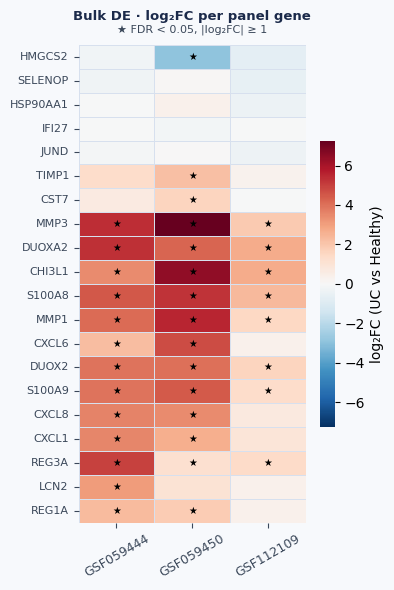

In [11]:
# show DE results as a heatmap
plot_bulk_de_heatmap(
    de_results,
    genes,
    fdr_threshold=FDR_THRESHOLD,
    log2fc_threshold=LOG2FC_THRESHOLD,
    figsize=(4, 6),
    contrast_label=CONTRAST_LABEL,
)

> **Reading this figure.**
>
> **Colour** = log2FC (tissue-level contrasts per dataset).
> Among shown tiles, an **asterisk (*)** indicates that the gene meets the threshold for significance (|log2FC| ≥ 1, FDR < 0.05).

## Step 3 · Single-cell data analysis

**Do we have a valid cohort which can be used for DE analysis? What is the expression profile of each cell type?**

**Which genes are differentially expressed between case and control cells?**

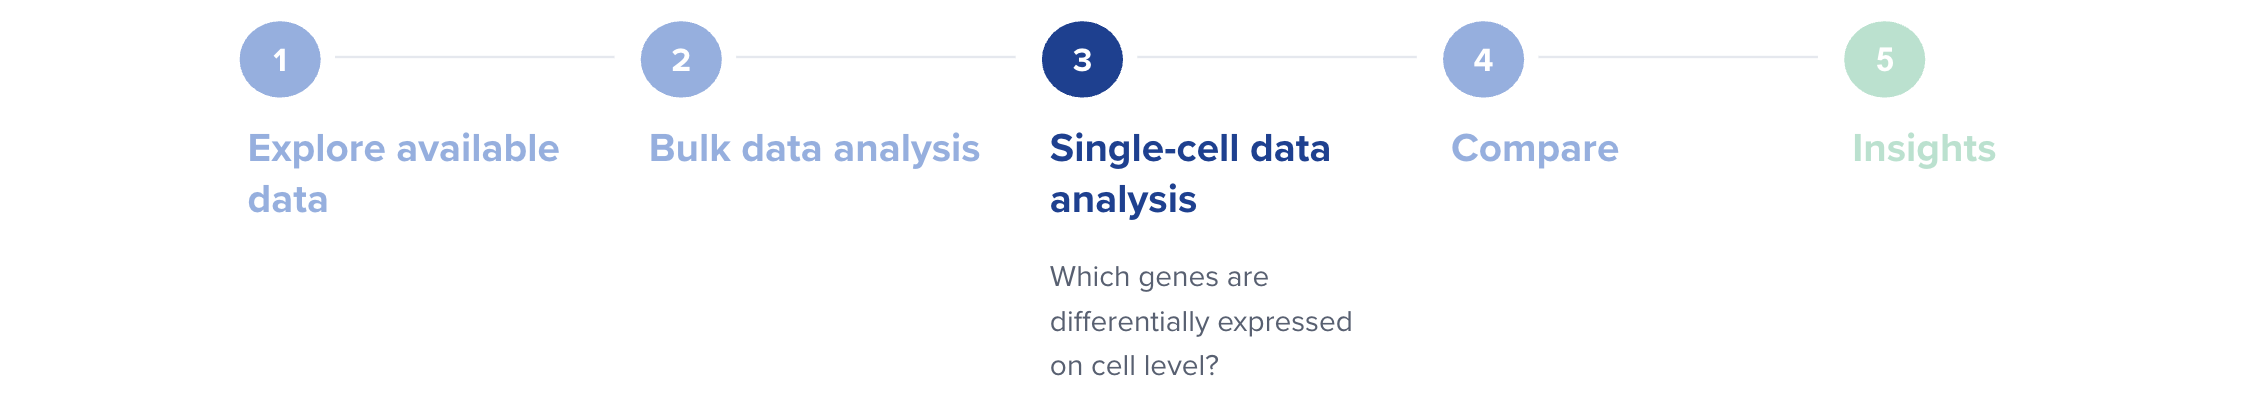

### 3.1 Set cohort parameters
To retrieve single-cell expression, we need to filter the datasets the same way as we previously filtered bulk RNA-seq datasets.

In [12]:
# case / control query params (derived from cohort config)
case_query_params = {
    'sample_filter': CASE_FILTER
}
control_query_params = {
    'sample_filter': CTRL_FILTER
}
print(f"Cohort: {CONTRAST_LABEL} · tissue={TISSUE} · {len(genes)} panel genes")

Cohort: UC vs Healthy · tissue=large intestine · 20 panel genes


### 3.2 Retrieve suitable single-cell datasets

In [13]:
def discover_studies_with_cells(api_client, max_studies=50, **kwargs):
    """
    Find studies that contain cells matching the given sample / cell filters.
    
    Parameters:
    - api_client (odm_api.ApiClient): Authenticated API client.
    - max_studies (int): Maximum number of matching studies to return.
    - **kwargs (dict): Optional keyword arguments for the 'omics_search' API call, 
        e.g. `{'sample_filter': 'Organism="Homo sapiens"'}`.
    
    Returns:
    - Up to max_studies dicts with keys 'accession' and 'name'.
    """
    omics_api = odm_api.OmicsQueriesAsUserApi(api_client)
    study_api = odm_api.StudySPoTAsUserApi(api_client)

    all_studies = get_all_data(study_api.search_studies_as_user)
    matching = []
    for study in all_studies:
        accession = study.get('genestack:accession')
        if not accession:
            continue
        cells = omics_api.omics_search_cells_as_user(
            study_query=accession, page_limit=1, **kwargs
        ).data
        if cells:
            matching.append({
                'accession': accession,
                'name': study.get('Study Title', accession),
            })
        if len(matching) >= max_studies:
            break
    return matching


# --- get single-cell studies ---
with odm_timer(f'Finding single-cell studies with {CASE_LABEL} cells'):
    case_studies = discover_studies_with_cells(api_client, **case_query_params)
    
print(f"Found {len(case_studies)} single-cell studies with '{CASE_GROUP}' cells:")
for study in case_studies:
    print(f"  {study['accession']}: {study['name']}")

Found 5 single-cell studies with 'ulcerative colitis' cells:
  GSF006253: Heterogeneity and clonal relationships of adaptive immune cells in ulcerative colitis revealed by single-cell analyses
  GSF006330: Single-cell atlas of colonic CD8+ T cells in ulcerative colitis
  GSF006390: A longitudinal single-cell atlas of anti-tumour necrosis factor treatment in inflammatory bowel disease
  GSF053512: IL-1-driven stromal–neutrophil interactions define a subset of patients with inflammatory bowel disease that does not respond to therapies
  GSF053553: Single-cell integration reveals metaplasia in inflammatory gut diseases (Large intestine)


### 3.3 Explore cell-type composition of the datasets

In this step the validity of the filtered cohort is verified. 

How heterogeneous is the filtered cohort? Are there both case and control cells per cell type to run the differential expression analysis?

#### 3.3.1 Get the list of unique cell types in the selected cohort

In [14]:
def get_cell_types(api_client, cell_type_attribute, cell_query=None, **kwargs):
    """
    List unique cell types from cell metadata.

    Parameters:
    - api_client (odm_api.ApiClient): API client instance.
    - cell_type_attribute (str): Cell type attribute name.
    - cell_query (str): Base cell query (optional).
    - **kwargs (dict): Optional keyword arguments for the 'omics_search' API call, 
        e.g. `{'sample_filter': 'Organism="Homo sapiens"'}`.

    Returns:
    - cell_types (list): List of unique cell types or empty list if no cells were found.
    """   
    omics_api = odm_api.OmicsQueriesAsUserApi(api_client)

    # get the first value of cell types
    cell_metadata = omics_api.omics_search_cells_as_user(
        cell_query=cell_query,
        page_limit=1,
        **kwargs
    ).data
    if cell_metadata:
        cell_types = [cell_metadata[0][cell_type_attribute]]
    else:
        return []

    # extract cell types excluding already listed
    while True:
        cell_quote = '","'.join(cell_types)
        cell_type_query = f'"{cell_type_attribute}"!="{cell_quote}"'
        if cell_query:
            cell_type_query = f'{cell_type_query} AND {cell_query}'
        next_cells = omics_api.omics_search_cells_as_user(
            cell_query=cell_type_query,
            page_limit=1,
            **kwargs
        ).data
        if next_cells:
            cell_types.append(next_cells[0][cell_type_attribute])
        else:
            break

    return list(sorted(cell_types))   


# --- get list of unique cell types ---
with odm_timer('Get unique cell types in the selected cohort'):
    cell_types = get_cell_types(
        api_client, 'cellType', **case_query_params
    )

#### 3.3.2 Calculate cell proportion in ODM  with cell_ratio
The cell_ratio API endpoint allows to retrieve already calculated cell proportions directly from ODM.

In [15]:
def get_cell_type_counts(api_client, cell_types, **kwargs):
    """
    Get cell counts for cell types.

    Parameters:
    - api_client (odm_api.ApiClient): API client instance.
    - cell_types (list or dict): List of cell types or named dict of cell type queries.
    - **kwargs (dict): Optional keyword arguments for the `DERequestCaseGroup` request model, 
        e.g. `{'sampleFilter': 'Organism="Homo sapiens"'}`.

    Returns:
    - df (pd.DataFrame): DataFrame with cell type counts.
    """
    analytics_api = odm_api.BETAAnalyticsOmicsQueriesAsUserApi(api_client)
    shared_params = camel_case_keys(kwargs)

    # define cell type queries dict
    cell_type_queries = (
        {cell_type: f'cellType="{cell_type}"' for cell_type in cell_types}
        if isinstance(cell_types, list)
        else cell_types
    )

    # iterate over cell types
    cell_type_counts_dict = {}
    for cell_type, cell_query in cell_type_queries.items():

        # retrieve cell type counts
        cr_response = analytics_api.cell_ratio_as_user(
            cr_request=CRRequest(
                cellGroup=DERequestCaseGroup(cellQuery=cell_query, **shared_params)
            )
        )
        cell_type_counts_dict[cell_type] = cr_response.count_selected

    # return as dataframe
    df = pd.DataFrame(
        list(cell_type_counts_dict.items()), 
        columns=['cell_type', 'total_count']
    )
    return df


# --- get cell type counts ---
with odm_timer(f'Counting cells per type — {CONTRAST_LABEL}', key='cell_type_counts'):
    cell_type_counts_df = get_cell_type_counts(
        api_client, cell_types, **case_query_params
    )
    cell_type_counts_ctrl_df = get_cell_type_counts(
        api_client, cell_types, **control_query_params)

#### 3.3.3 Cell-type composition results
The graph is built based on the results retrieved in a previous cell with cell_ratio endpoint. Each bar on the graph is one API call.

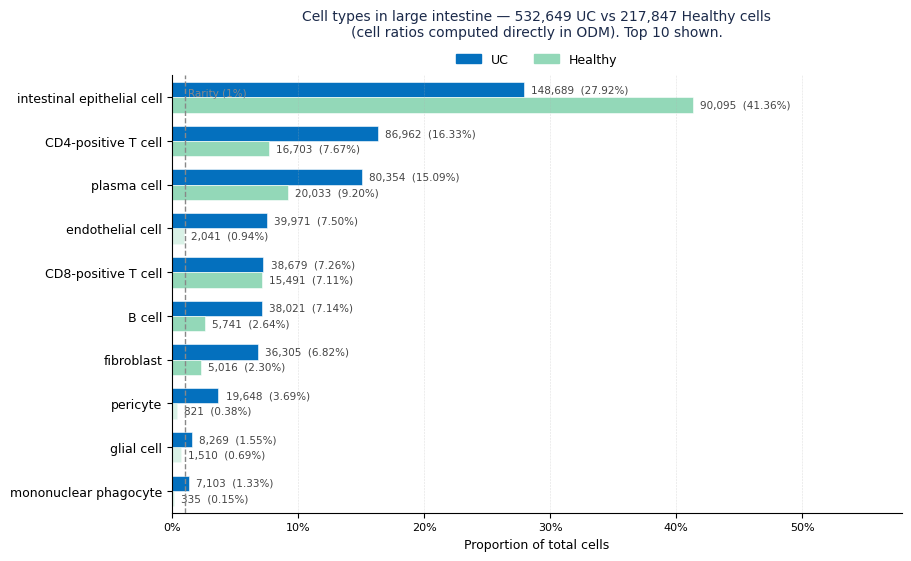

In [16]:
# plot cell type proportions
_total_case = int(cell_type_counts_df['total_count'].sum())
_total_ctrl = int(cell_type_counts_ctrl_df['total_count'].sum())
_tissue_bit = f' in {TISSUE}' if TISSUE else ''
_plot_title = (
    f"Cell types{_tissue_bit} — {_total_case:,} {CASE_LABEL} vs {_total_ctrl:,} {CTRL_LABEL} cells "
    f"(cell ratios computed directly in ODM). Top 10 shown."
)
plot_cell_type_proportions_comparison(
    cell_type_counts_df,
    cell_type_counts_ctrl_df,
    case_label=CASE_LABEL,
    ctrl_label=CTRL_LABEL,
    top_n=10,
    title=_plot_title,
    legend_loc='top',
)

### 3.4 Characterize expression of selected genes per cell type
How each gene from the panel is expressed in different cell types in case group samples? How specific is this expression?

#### 3.4.1 Retrieve cell expression with gene_summary
To build a figure, the mean gene expression value and a number of cells expressing this gene are needed. These values can be retrieved directly from ODM with gene_summary API endpoint.

In [17]:
def get_genes_summary_per_cell_type(api_client, genes, cell_types, **kwargs):
    """
    Get gene summary for cell types.

    Parameters:
    - api_client (odm_api.ApiClient): API client instance.
    - genes (list): List of gene names.
    - cell_types (list or dict): List of cell types or named dict of cell type queries.
    - **kwargs (dict): Optional keyword arguments for the `DERequestCaseGroup` request model, 
        e.g. `{'sampleFilter': 'Organism="Homo sapiens"'}`.

    Returns:
    - gs_df (pd.DataFrame): DataFrame with gene summary.
    """
    analytics_api = odm_api.BETAAnalyticsOmicsQueriesAsUserApi(api_client)
    shared_params = camel_case_keys(kwargs)

    # define cell type queries dict
    cell_type_queries = (
        {cell_type: f'cellType="{cell_type}"' for cell_type in cell_types}
        if isinstance(cell_types, list)
        else cell_types
    )

    # iterate over cell types
    gs_list = []
    for cell_type, cell_query in cell_type_queries.items():

        # retrieve gene summary statistics
        gs_response = analytics_api.gene_summary_as_user(
            gs_request=GSRequest(
                geneNames=genes,
                cellGroup=DERequestCaseGroup(cellQuery=cell_query, **shared_params)
            )
        )
        
        # generate and format data frame
        df = pd.DataFrame(gs_response.results_per_gene)
        df["cell_type"] = [("cell_type", cell_type)] * len(df)
        gs_list.append(df)
        
    # combine all cells into a single metadata table
    gs_df = pd.concat(gs_list)
    col_names = [cell[0] for cell in gs_df.iloc[0]]
    gs_df = gs_df.map(lambda x: x[1])
    gs_df.columns = col_names
    gs_df = gs_df.sort_values('gene_id')

    return gs_df


# --- get gene summary per cell type ---
with odm_timer(f'Querying per-cell-type expression for {len(genes)} panel genes', key='gene_summary'):
    gene_summary_df = get_genes_summary_per_cell_type(
        api_client, genes, cell_types, **case_query_params
    )

# --- add cell type counts to gene summary df ---
gene_cell_summary_df = pd.merge(gene_summary_df, cell_type_counts_df, on='cell_type', how='left')

# --- compute cell-specificity score ---
gene_cell_summary_df = score_cell_specificity(gene_cell_summary_df)

#### 3.4.2 Expression per cell type results
Where is the signal concentrated? With the visual representation it is possible to see how high is the expression of a gene in each cell type and how frequently do specific cells express a specific gene.

The dot plot is built based on the result of the previous cell. A separate API call is executed for each column, retrieving the whole gene panel expression for a cell type in less than a second.

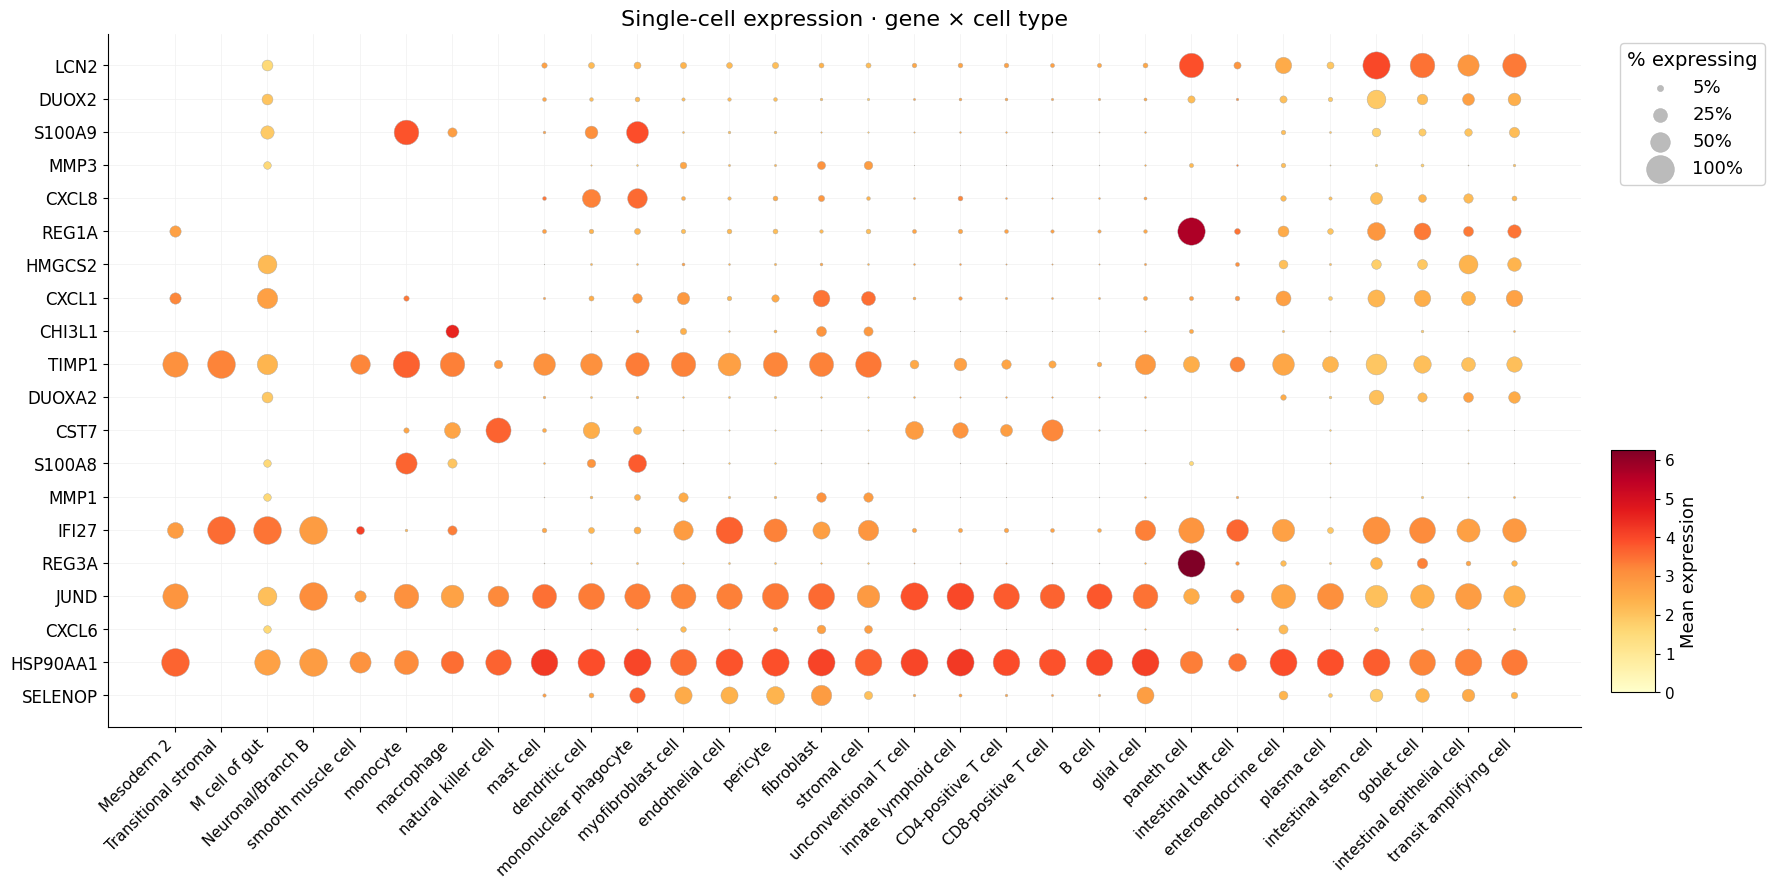

In [18]:
# dot plot: size = % expressing, colour = mean expression
plot_sc_dotplot(gene_cell_summary_df, genes_order=genes)

>**Reading this figure.**
>
>**Dot size** = proportion of cells expressing the gene, **dot colour** = mean expression of the gene.

#### 3.4.3 Check cross-dataset reproducibility of results

Is gene expression in a specific cell type in case group samples reproducible across datasets? In ODM you can easily get the result for the whole cross-dataset cohort or check in a specific study to verify the absence of a batch effect.

Below we rebuild per-cell-type ranking in each dataset independently for the first gene from the panel.

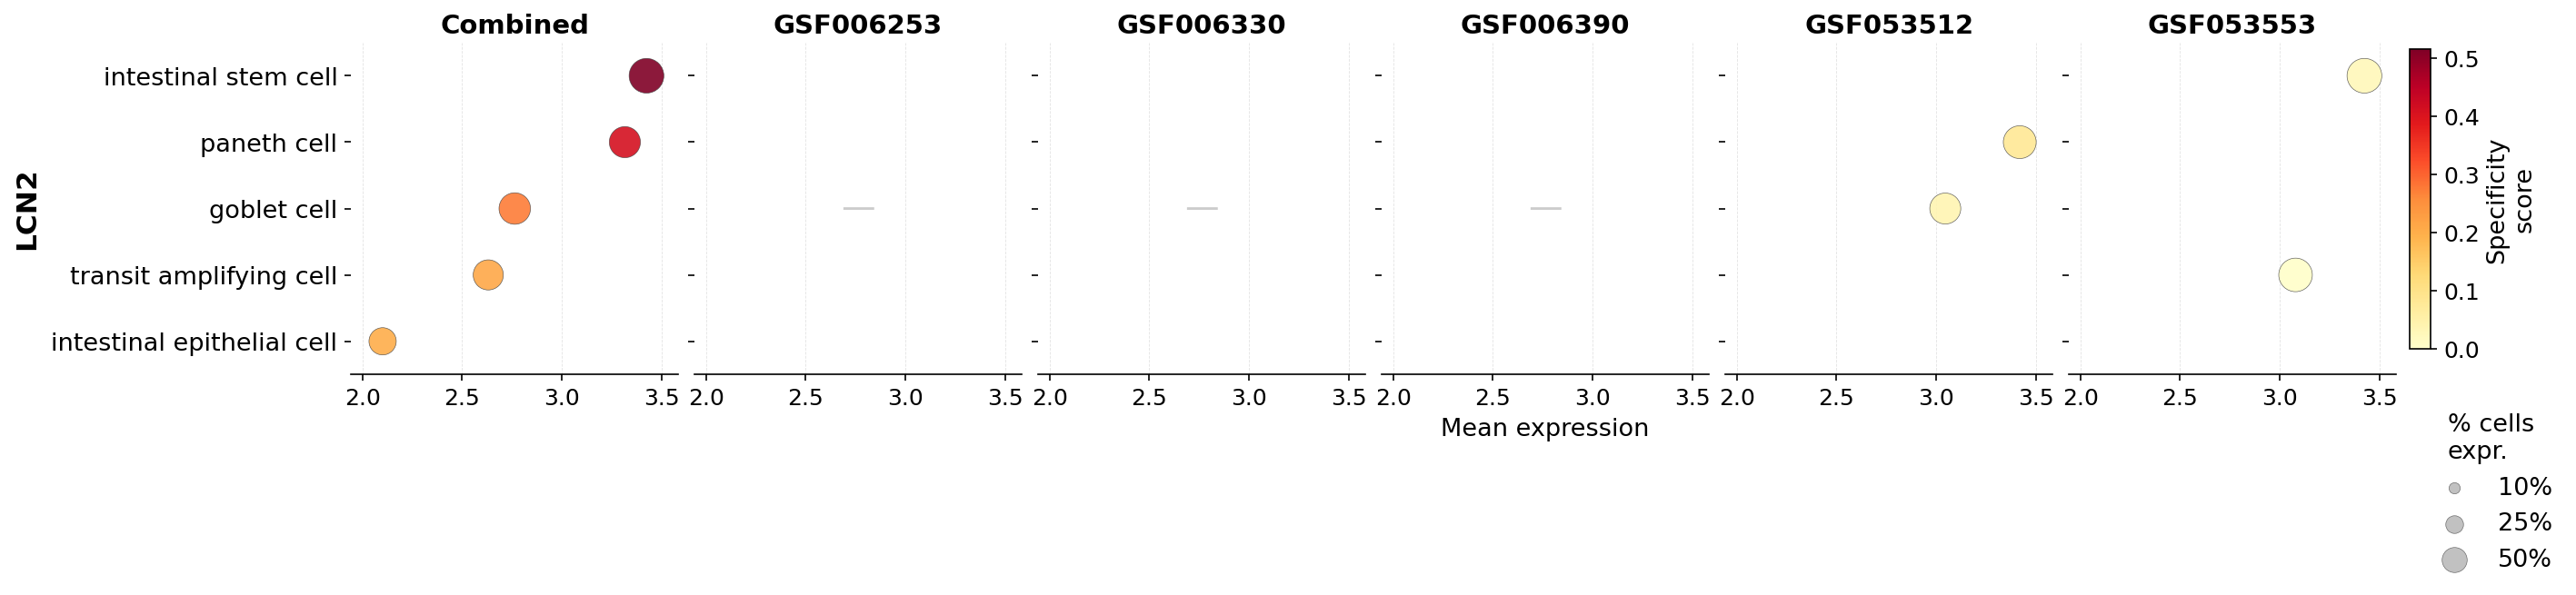

In [19]:
# cell summary parameters
n_top = 10
cell_count_threshold = 5

# get top cell types
top_cell_types_dict = {}
for gene in genes:
    top_cell_types_dict[gene] = get_top_cell_types(
        gene_cell_summary_df, gene, n_top, cell_count_threshold
    )
top_cell_types_df = pd.concat(top_cell_types_dict.values(), ignore_index=True)
top_cell_types = top_cell_types_df['cell_type'].unique()

# select a gene to display
gene=genes[0]

# get cross-dataset results for selected gene
with odm_timer(f'Reproducibility across studies — {gene}'):
    
    display_genes = [gene]
    _combined_top = get_top_cell_types(gene_cell_summary_df, gene, n_top, cell_count_threshold)
    _study_cell_types = _combined_top['cell_type'].unique().tolist()
    _per_study_top = []

    for study in case_studies:
        accession = study['accession']
        label = accession

        study_case_params = {
            **case_query_params,
            'study_filter': f'"genestack:accession"="{accession}"'
        }

        _counts = get_cell_type_counts(api_client, _study_cell_types, **study_case_params)
        if _counts['total_count'].sum() == 0:
            _per_study_top.append((label, pd.DataFrame()))
            continue

        try:
            _summary = get_genes_summary_per_cell_type(
                api_client, [gene], _study_cell_types, **study_case_params
            )
        except IndexError:
            _per_study_top.append((label, pd.DataFrame()))
            continue

        _merged = score_cell_specificity(pd.merge(_summary, _counts, on='cell_type', how='left'))

        g = get_top_cell_types(_merged, gene, n_top, cell_count_threshold)

        _per_study_top.append((label, g))

# plot comparison of expression in top cell types by source
plot_sc_dotplot_and_cell_summary_source_comparison(_combined_top, _per_study_top, display_genes)

> **Reading this figure.**
>
> Rows are cell types, columns are studies (plus the combined view in the beginning). **Dot size** = proportion of cells expressing the gene, **X-axis** = mean expression of the gene, **dot colour** = specificity score. Specificity score shows how much more a gene stands out (higher level and higher % expressing) in a specific cell type vs. all other cell types combined.
>
> When a gene has different expression patterns across independent studies, that can be a sign to investigate further.

#### 3.4.4 Retrieve per-study cell composition
The differences observed might be related to the cell composition of each particular dataset.

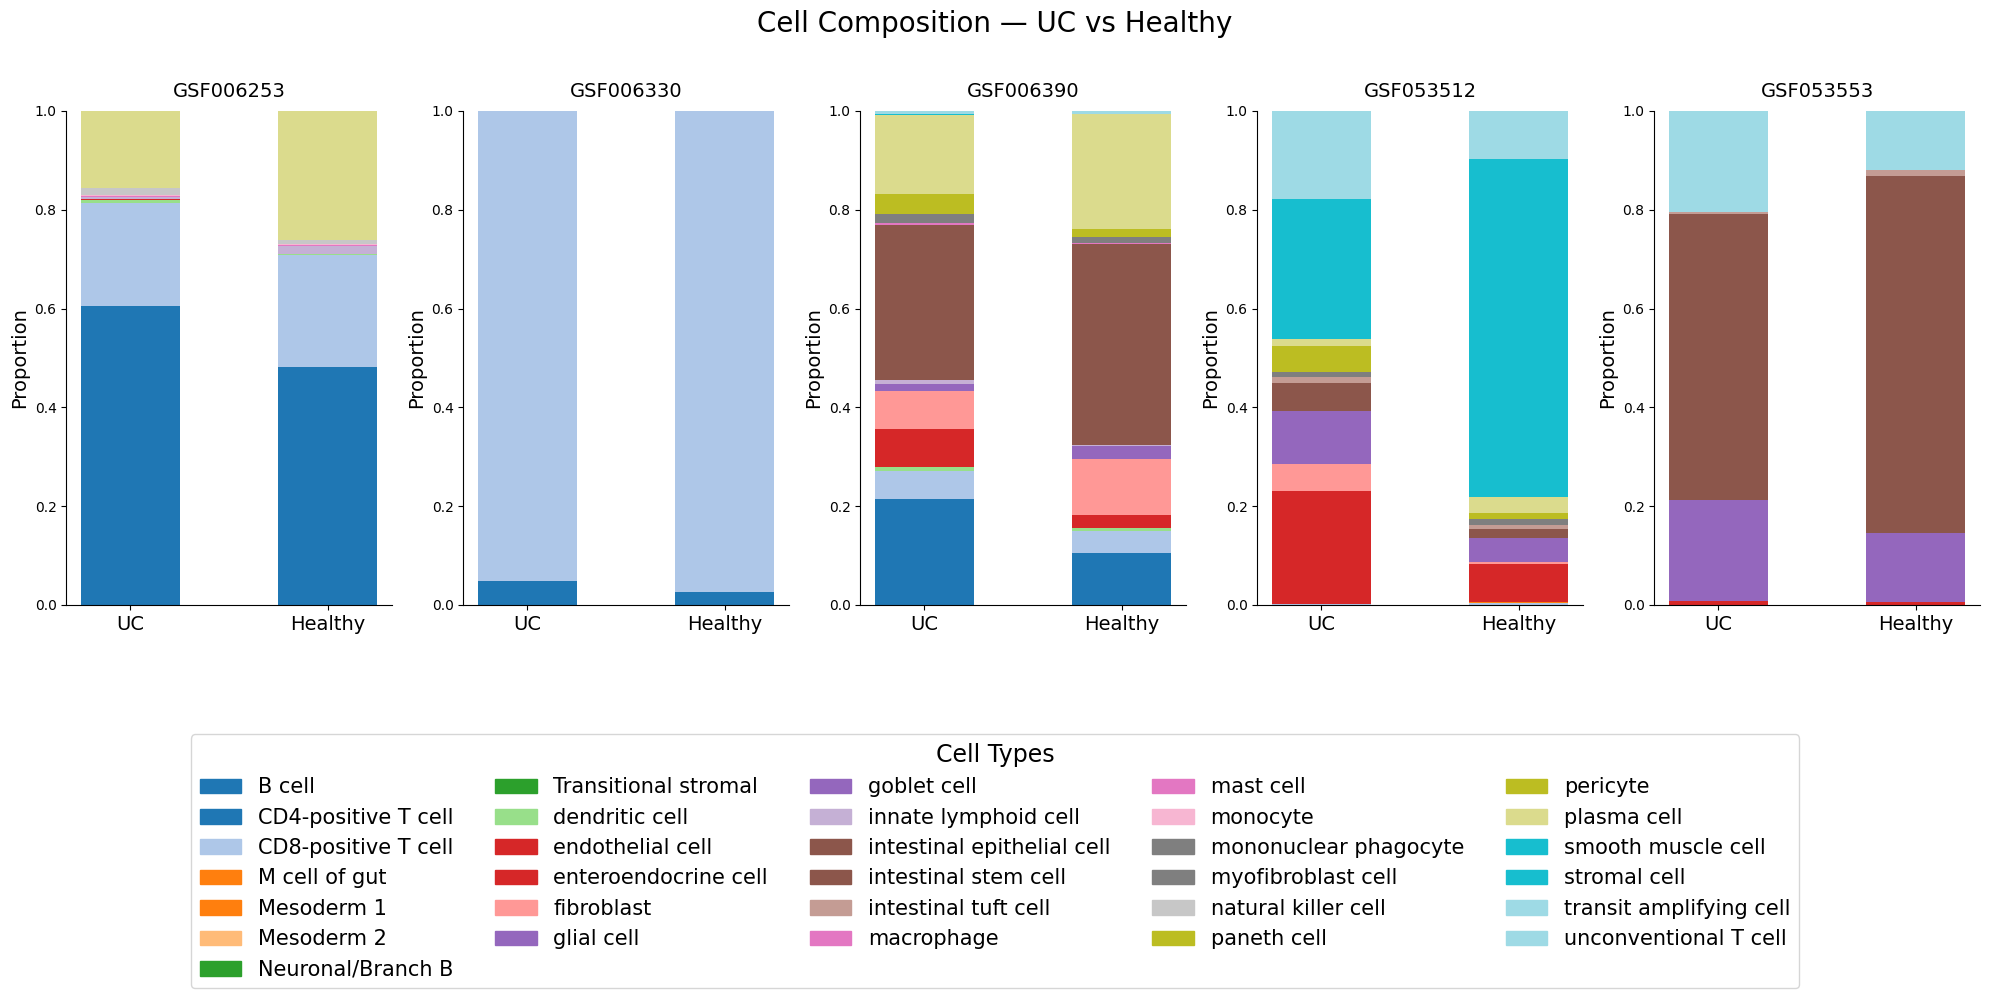

In [20]:
# compare cell type composition between datasets
with odm_timer('Cell composition per study'):
    
    all_study_counts = {}
    for study in case_studies:
        acc  = study['accession']
        name = study['name']
        case_q = {**case_query_params, 'study_filter': f'"genestack:accession"="{acc}"'}
        ctrl_q = {**control_query_params, 'study_filter': f'"genestack:accession"="{acc}"'}
        try:
            ct = get_cell_types(api_client, 'cellType', **case_q)
            if not ct:
                continue
            counts_case = get_cell_type_counts(api_client, ct, **case_q)
            counts_ctrl = get_cell_type_counts(api_client, ct, **ctrl_q)
            if counts_ctrl['total_count'].sum() == 0:
                continue
            all_study_counts[acc] = {
                'case': counts_case,
                'ctrl': counts_ctrl,
                'cell_types': ct,
                'name': name,
            }
        except Exception as e:
            print(f"{acc}: {e}")

plot_cell_composition(all_study_counts, CASE_LABEL, CTRL_LABEL)

### 3.5 Calculate single-cell DE on the defined gene panel
Differential expression of the panel genes is calculated per each cell type across the chosen cohort. All calculations are done inside of ODM and retrieved with analytical endpoints.

#### 3.5.1 Define quality filters
Build high-quality cell filter.

In [21]:
# define cell query
cell_quality_filter = ' AND '.join([
    'percentMito < 20',
    '(nCounts > 1000 AND nCounts < 15000)'
])

#### 3.5.2 Set functions for retrieving DE results directly from ODM
Functions are needed mostly for iteration when using differential_expression API endpoint.

In [22]:
def run_single_cell_de_analysis(
    api_client, case_group_params, control_group_params, ex_query=None
):
    """
    Run differential expression analysis for a given case and control group.

    Parameters:
    - api_client (odm_api.ApiClient): API client instance.
    - case_group_params (dict): Case group parameters for the `DERequestCaseGroup` request model,
        e.g. `{'sampleFilter': 'Organism="Homo sapiens"'}`.
    - control_group_params (dict): Control group parameters for the `DERequestCaseGroup` request model,
        e.g. `{'sampleFilter': 'Organism="Homo sapiens"'}`.
    - ex_query (str): Features to query (e.g. 'feature=MKI67,TOP2A').

    Returns:
    - pd.DataFrame or None: DE results, or None if no genes were returned.
    """
    analytics_api = odm_api.BETAAnalyticsOmicsQueriesAsUserApi(api_client)
    case_group_params = camel_case_keys(case_group_params)
    control_group_params = camel_case_keys(control_group_params)

    # retrieve differential expression results
    offset = 0
    limit = 20000
    de_response_list = []
    while True:
        de_response = analytics_api.differential_expression_as_user(
            de_request=DERequest(
                caseGroup=DERequestCaseGroup(**case_group_params),
                controlGroup=DERequestCaseGroup(**control_group_params),
                exQuery=ex_query,
                limit=limit,
                offset=offset
            )
        )
        offset = offset + limit
        
        # generate and format data frame
        df = pd.DataFrame(item.model_dump() for item in de_response.results_per_gene)
        de_response_list.append(df)
        
        if len(de_response.results_per_gene) < limit:
            break

    # combine all results into a single table
    de_results_df = pd.concat(de_response_list, ignore_index=True)

    # return None if the API returned no genes (e.g. no cells matched the query)
    if de_results_df.empty or 'p_value' not in de_results_df.columns:
        return None

    # replace zero and NaN p-values with the capped minimum and maximum
    de_results_df.loc[de_results_df['p_value'] == 0, 'p_value'] = 1e-16
    de_results_df.loc[de_results_df['p_value'].isna(), 'p_value'] = 1

    # compute false discovery rate
    de_results_df['fdr'] = false_discovery_control(de_results_df['p_value'], method='bh')

    return de_results_df

#### 3.5.3 Run DE analysis
Differential expression for the **panel genes**, computed within *each* cell type.

In [23]:
SC_LOG2FC_THRESHOLD = 0.25


with odm_timer(f'{CONTRAST_LABEL} DE within each cell type', key='panel_sc_de'):
    
    # iterate over top cell types
    de_results_dict = {}
    panel_ex_query = 'feature=' + ','.join(f'"{g}"' for g in genes)
    for cell_type in top_cell_types:

        # define cell query
        cell_query = ' AND '.join([
            f'cellType="{cell_type}"',
            cell_quality_filter
        ])

        # run DE analysis for case-vs-control comparison within the cell type
        de_results_df = run_single_cell_de_analysis(
            api_client, 
            case_group_params = {'cellQuery': cell_query, **case_query_params}, 
            control_group_params = {'cellQuery': cell_query, **control_query_params},
            ex_query=panel_ex_query,
        )
        if de_results_df is None:
            print(f"Skipping {cell_type}: no DE results returned")
            continue
        de_results_dict[cell_type] = de_results_df

# summary table: for each panel gene, which cell types it is DE in.
_sc_rows = []
for ct, df in de_results_dict.items():
    sig = df[(df['fdr'] < FDR_THRESHOLD) & (df['log2_fc'].abs() >= SC_LOG2FC_THRESHOLD)]
    for _, r in sig.iterrows():
        _sc_rows.append({'gene': r['gene_id'], 'cell_type': ct,
                         'log2FC': round(r['log2_fc'], 2), 'FDR': f"{r['fdr']:.1e}"})
_sc_summary = pd.DataFrame(_sc_rows)
if len(_sc_summary):
    _sc_summary = (_sc_summary.sort_values(['gene', 'log2FC'], ascending=[True, False])
                              .reset_index(drop=True))
    display_collapsible_table(
        f"Single-cell DE summary — {_sc_summary['gene'].nunique()} panel genes "
        f"significant in {_sc_summary['cell_type'].nunique()} cell types (click to expand)",
        _sc_summary.to_html(index=False), open_by_default=True
    )
else:
    print("No panel genes passed the single-cell DE thresholds.")

gene,cell_type,log2FC,FDR
CHI3L1,fibroblast,0.49,1.1e-05
CST7,natural killer cell,0.30,6.0e-16
CXCL1,transit amplifying cell,0.54,2.5e-16
CXCL1,goblet cell,0.42,4.4e-07
CXCL1,intestinal epithelial cell,0.40,1.8e-16
CXCL1,stromal cell,0.29,5.0e-16
CXCL1,endothelial cell,-0.41,2.2e-02
CXCL6,stromal cell,0.26,1.6e-06
CXCL8,pericyte,0.80,2.1e-02
CXCL8,transit amplifying cell,0.32,9.3e-03


## Step 4 · Compare bulk vs single-cell
**Is it possible to find more significant genes with single-cell data analysis? What cell types drive the signal observed in bulk transcriptomics data?**

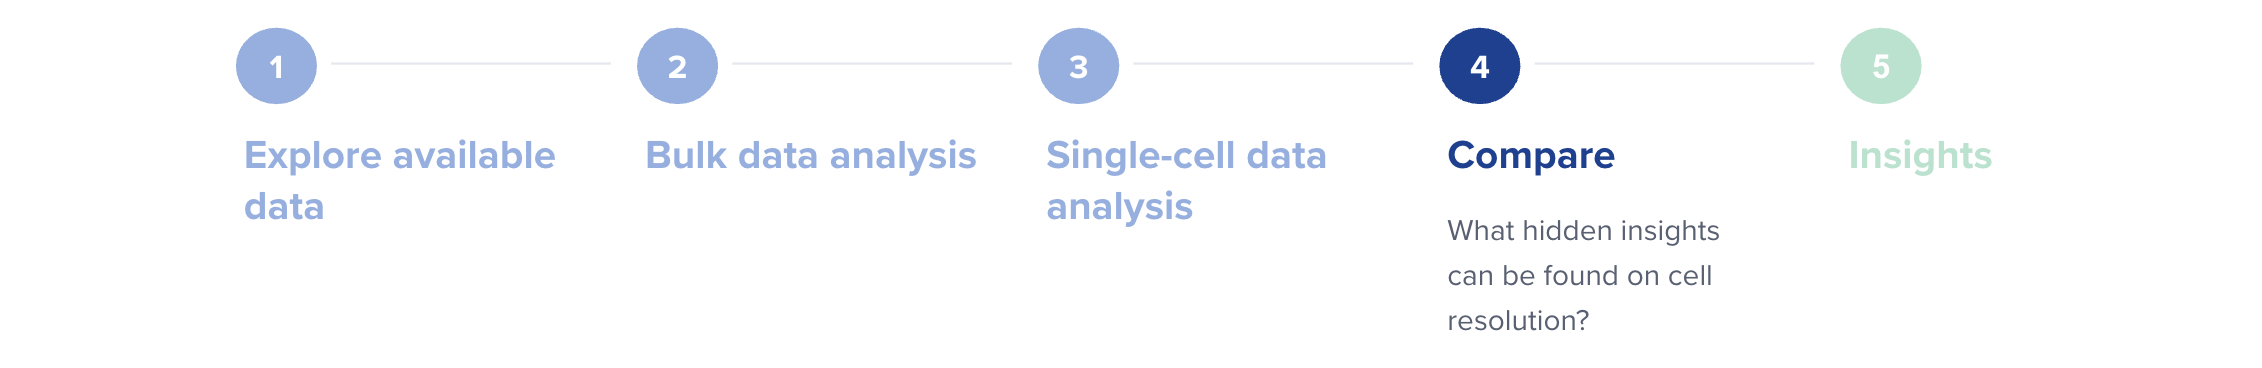

### 4.1 Bulk vs single-cell DE heatmap
Side-by-side comparison allows to find the genes that are not differentially expressed in the bulk tissue analysis but are significant in specific cell types. The heatmap is built based on steps 2 and 3.

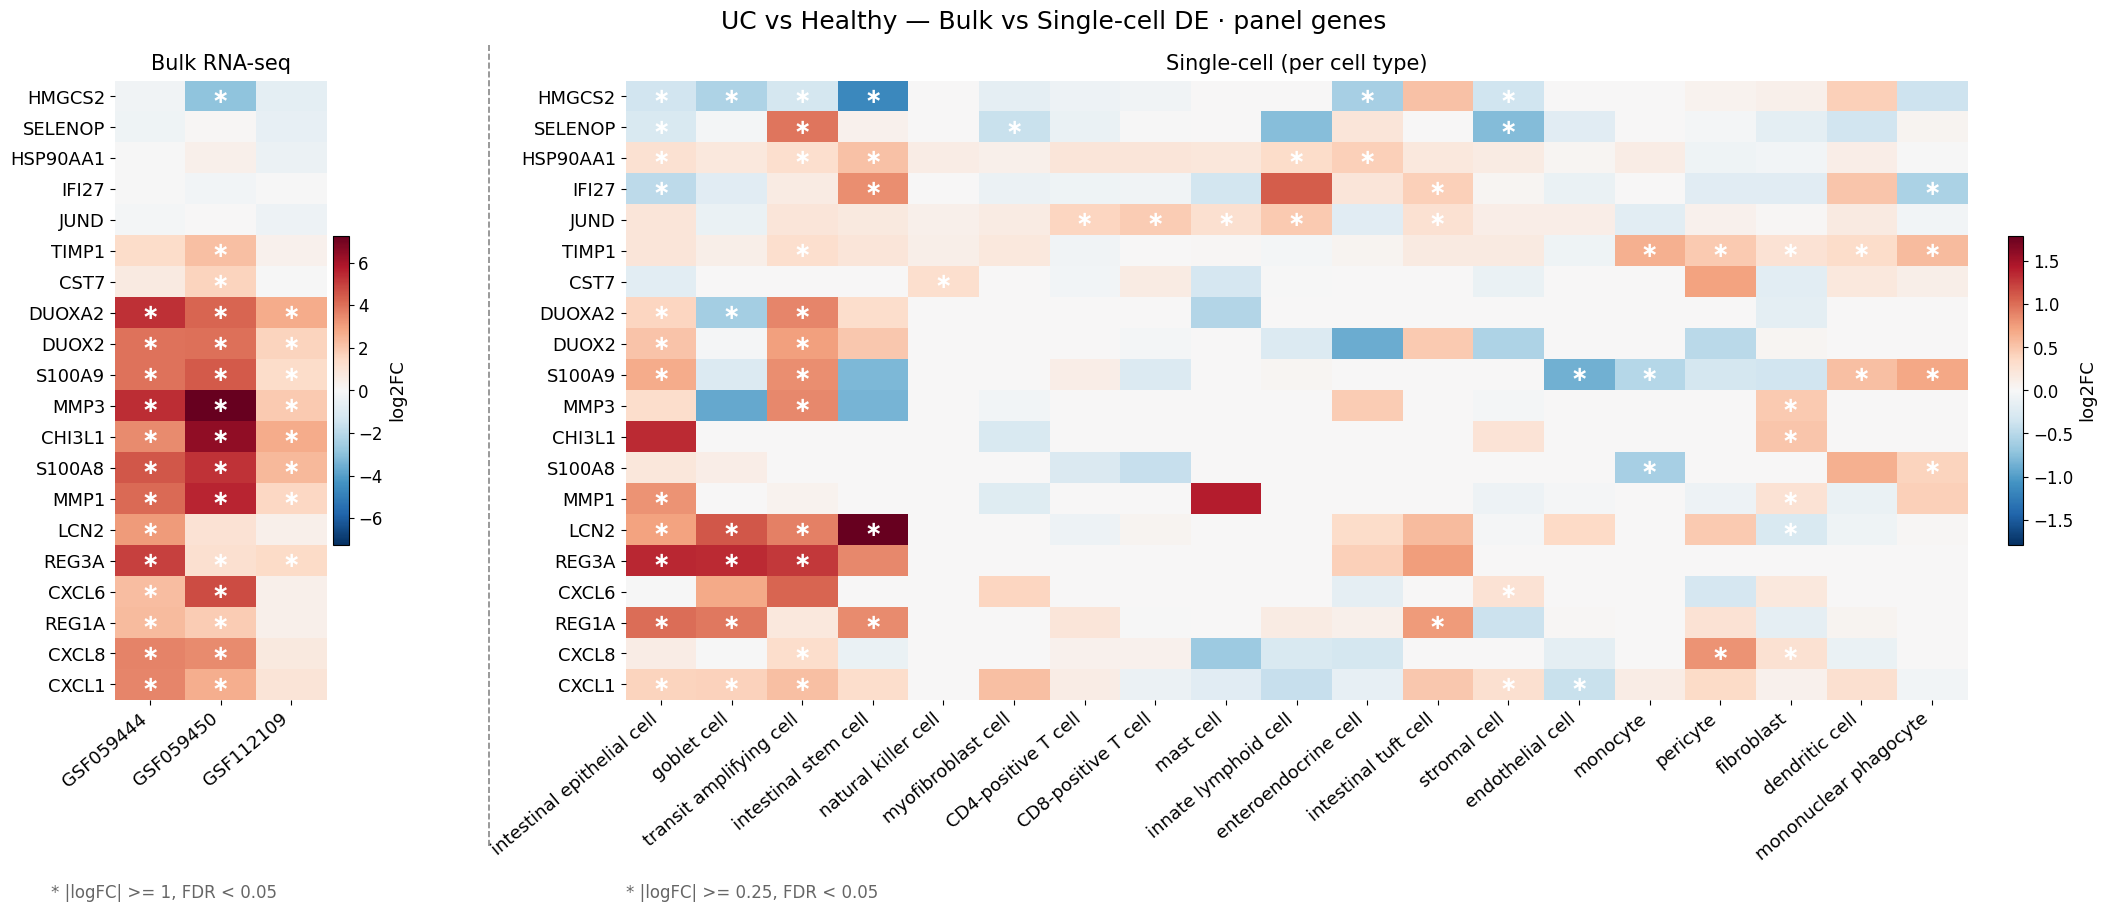

In [24]:
# show bulk vs single-cell DE heatmap
plot_bulk_sc_de_comparison(
    {k.split(' (')[0]: v for k, v in bulk_de_results.items()},
    de_results_dict,
    genes,
    fdr_threshold=FDR_THRESHOLD,
    bulk_log2fc_threshold=LOG2FC_THRESHOLD,
    sc_log2fc_threshold=SC_LOG2FC_THRESHOLD,
    title=f'{CONTRAST_LABEL} — Bulk vs Single-cell DE · panel genes',
)

> **Reading this figure.**
>
> **Colour scales** are modality-specific. Bulk RNA-seq log2FC values (left) are tissue-level contrasts per dataset; single-cell log2FC values (right) are computed within each cell type. Each panel is coloured relative to its own maximum, preserving visual resolution within each modality.
>
> Among shown tiles, an **asterisk (*)** indicates that the gene meets the threshold for significance.

### 4.2 The interactive summary table
This subsection helps to build a convenient summarizing table. For each panel gene, the table describes whether it is significant in bulk, in single-cell, in which cell type, and whether the two assays agree.

In [25]:
# show bulk vs single-cell DE summary table
display_bulk_sc_de_comparison_panel(
    genes_panel=genes,
    de_results_bulk=bulk_de_results,
    de_results_sc=de_results_dict,
    bulk_sig_genes=bulk_sig_gene_set,
    genes_from_panel=True,
    fdr_threshold=FDR_THRESHOLD,
    log2fc_threshold=LOG2FC_THRESHOLD,
    sc_fdr_thresh=FDR_THRESHOLD,
    sc_log2fc_thresh=SC_LOG2FC_THRESHOLD,
    title=f'{CASE_LABEL} Candidate Gene Panel',
    subtitle=f'Genes differentially expressed ({CONTRAST_LABEL})',
)

Gene ↕,Source ↕,Concordance ↕,GSF059444 ↕,GSF059450 ↕,GSF112109 ↕,SC cell types ↕


## Step 5 · Insights: pathway analysis
**Analytical query results can then be used in further analysis for generating numerous insights. One of the examples is the pathway analysis that allows to see how the differential expression of functionally related groups of genes shifts.**

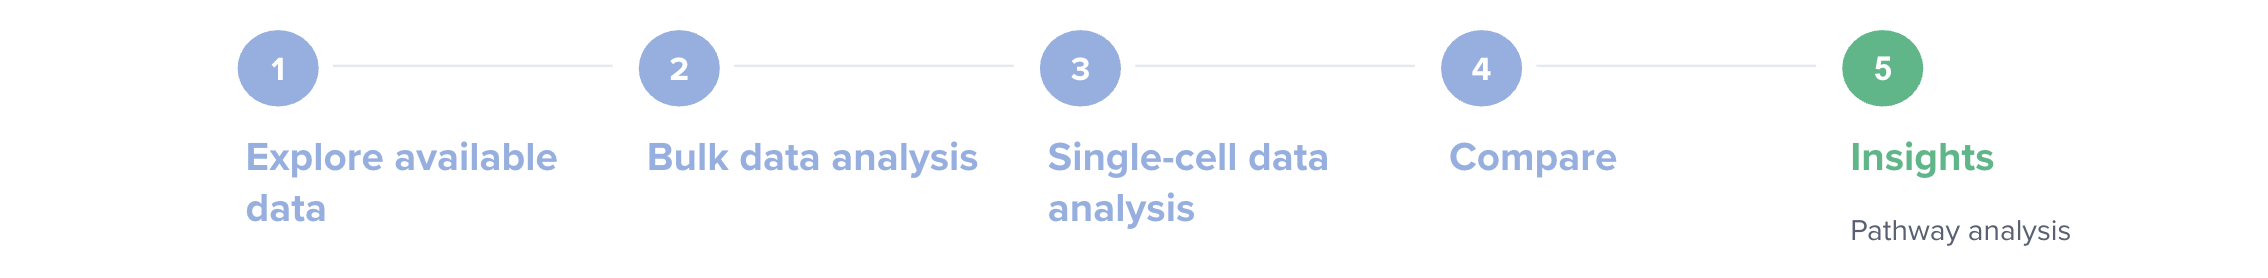

### 5.1 Genome-wide single-cell DE analysis
Gene set enrichment analysis (GSEA) needs a *genome-wide* single-cell DE.

In [26]:
with odm_timer('Genome-wide SC DE retrieving for pathway analysis', key='genomewide_sc_de'):        

    # iterate over top cell types
    gsea_cell_types = list(top_cell_types) # trim `gsea_cell_types` to fewer types to run faster.
    de_results_genomewide_dict = {}
    for cell_type in gsea_cell_types:

        # define cell query
        cell_query = ' AND '.join([
            f'cellType="{cell_type}"',
            cell_quality_filter
        ])

        # run DE analysis for case-vs-control comparison within the cell type
        de = run_single_cell_de_analysis(
            api_client, 
            case_group_params = {'cellQuery': cell_query, **case_query_params}, 
            control_group_params = {'cellQuery': cell_query, **control_query_params}
        )
        if de is not None and not de.empty:
            de_results_genomewide_dict[cell_type] = de
            
print(f"Genome-wide DE ready for {len(de_results_genomewide_dict)} cell types.")

Genome-wide DE ready for 25 cell types.


### 5.2 Gene set enrichment analysis (GSEA)
For the GSEA the MSigDB Hallmark gene sets collection is used. The DE result retrieved from ODM at the previous step is used for further calculations.

In [27]:
GENE_SETS_NAME = 'MSigDB_Hallmark_2020'

# check if genome-wide DE results are available
if de_results_genomewide_dict:
    _gsea_source = de_results_genomewide_dict
else:
    _gsea_source = de_results_dict
    print(
        "No genome-wide DE results found! "
        "GSEA with panel-only DE may be weakly powered or misleading."
    )

# run GSEA pre-ranked by log2_fc
print(f"Running preranked GSEA across {len(_gsea_source)} cell types...")
with open(os.devnull, 'w') as devnull, \
    contextlib.redirect_stdout(devnull), contextlib.redirect_stderr(devnull):
    gsea_results = run_gsea_per_cell_type(
        _gsea_source, 
        gene_sets=GENE_SETS_NAME,
        permutation_num=1000, 
        fdr_thresh=0.25,
    )
print(f"Pathway x cell-type pairs : {len(gsea_results)}")
print(f"Significant (FDR < 0.25)  : {int(gsea_results['significant'].sum())}")

Running preranked GSEA across 25 cell types...
Pathway x cell-type pairs : 1188
Significant (FDR < 0.25)  : 54


### 5.3 Pathway visualization
Visualization allows to see the coordinated functional changes in each cell type.

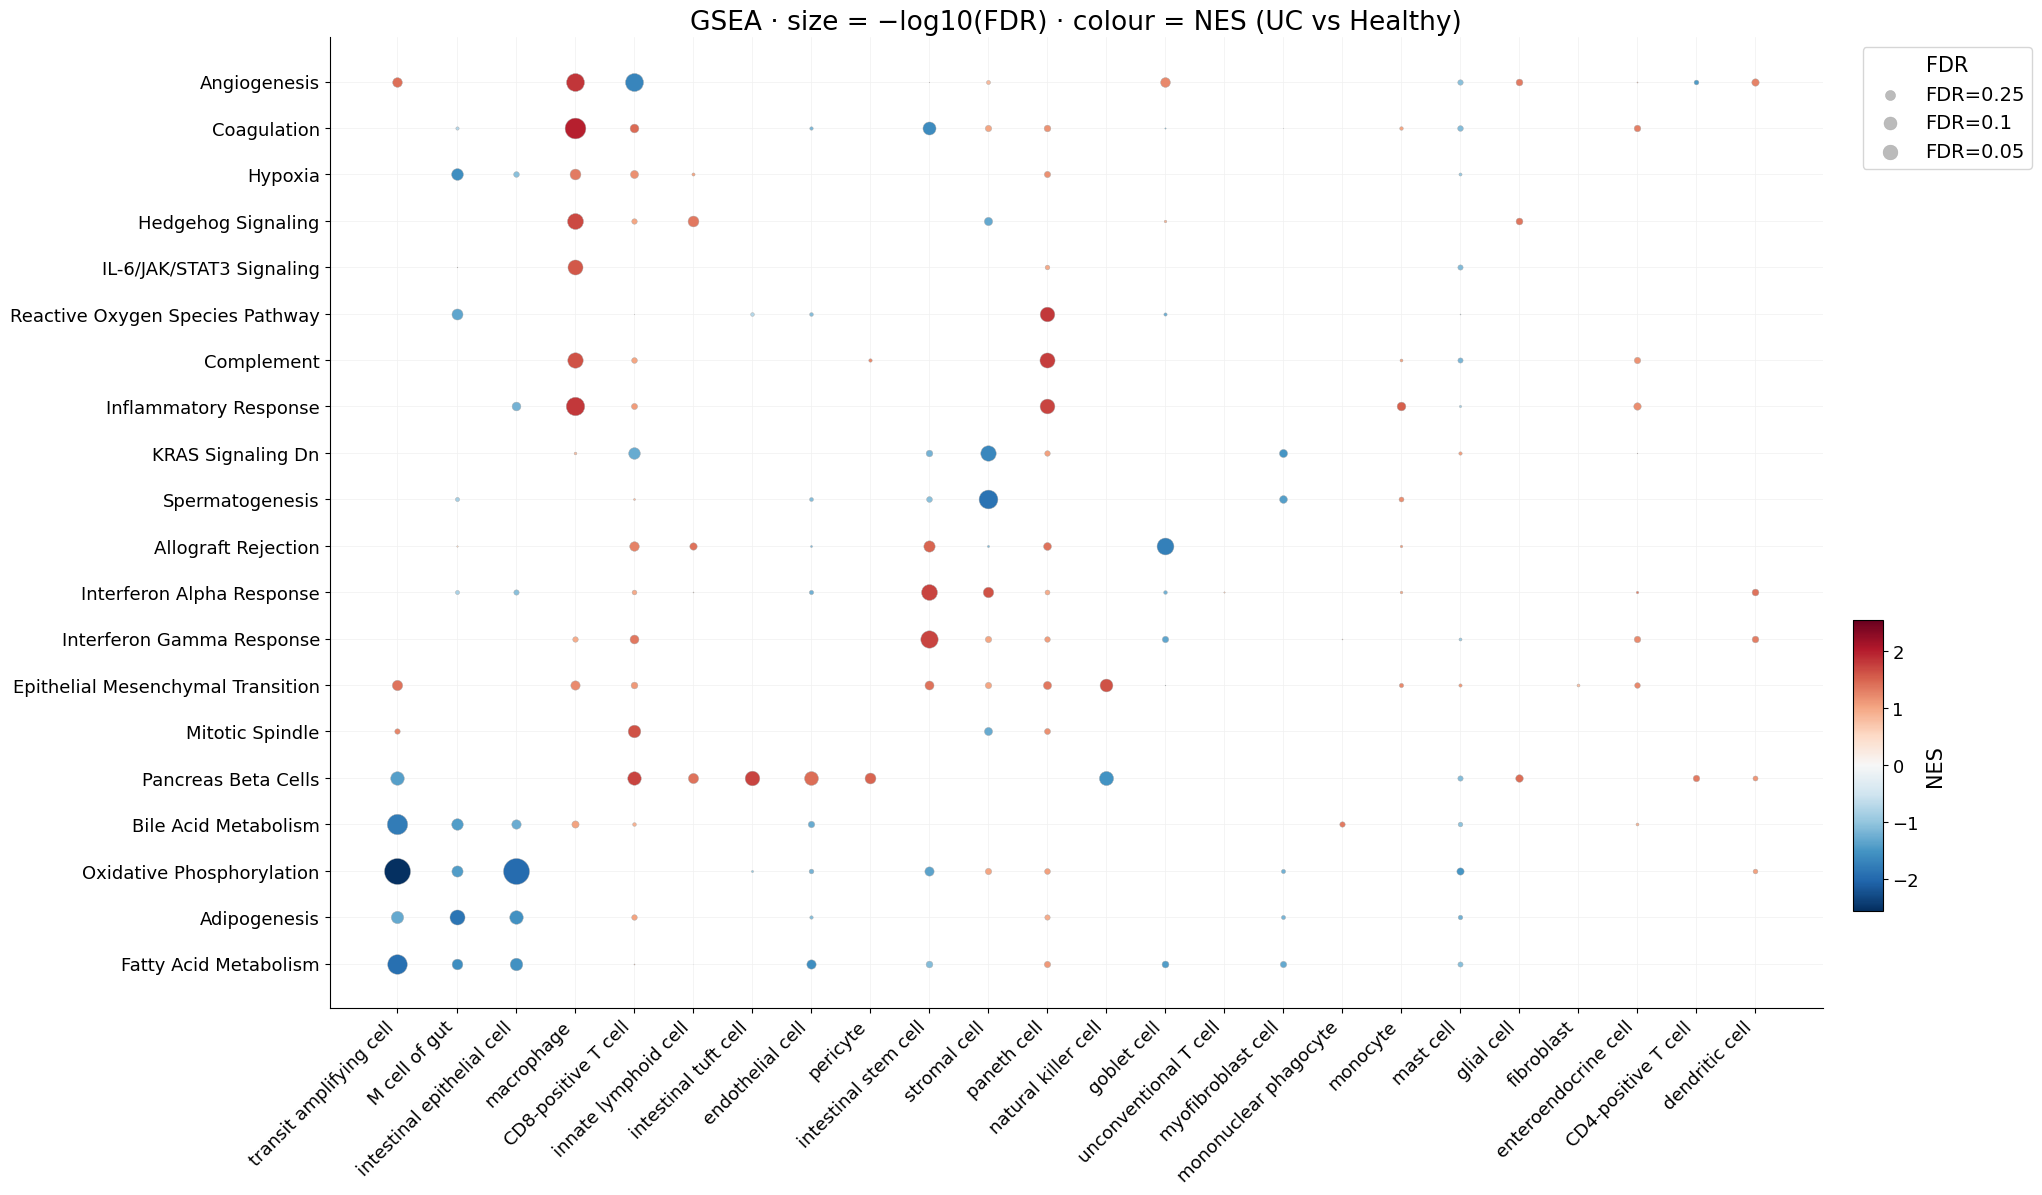

In [28]:
# show GSEA dotplot
plot_gsea_dotplot(
    gsea_results, top_n=20,
    title=f'GSEA · size = −log10(FDR) · colour = NES ({CONTRAST_LABEL})',
)

> **Reading this grid.**
>
> **Dot size** = FDR (False Discovery Rate), **dot colour** = NES (Normalized Enrichment Score).

## Summary


In [29]:
# generate analysis summary text
display_bulk_sc_comparison_summary(
    n_studies=n_studies,
    n_bulk_datasets=n_bulk_datasets,
    n_sc_datasets=n_sc_datasets,
    total_cells=total_cells,
    n_panel_genes=len(genes),
    n_cell_types=len(cell_types),
    n_panel_de_cell_types=len(de_results_dict),
    n_genomewide_cell_types=len(de_results_genomewide_dict),
    n_genomewide_genes=max((len(df) for df in de_results_genomewide_dict.values()), default=0),
)

# show analyzed data overview card
display_data_landscape(
    inventory_df,
    case_studies,
    cell_type_counts_df,
    cell_type_counts_ctrl_df,
    genes,
    case_col=CASE_COL,
    ctrl_col=CTRL_COL,
)

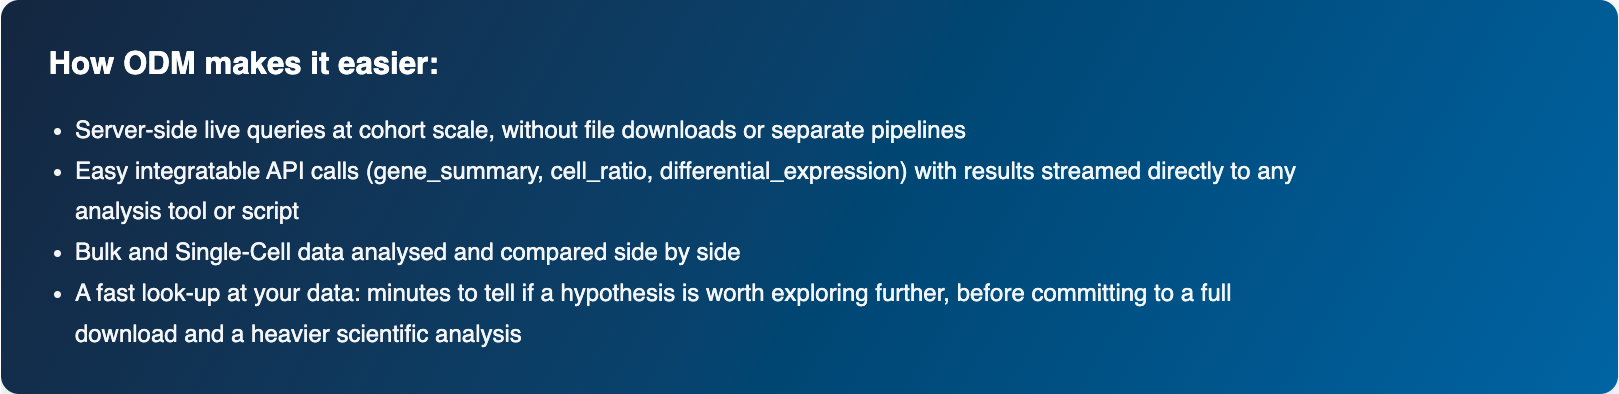